# Transferring to MSK-CHORD Patient Data

The purpose of this notebook is to transfer the cell line RSi model to patient data in the MSK-CHORD Database. This notebook can also serve as biomarker analysis.

## Code to stratify results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test


plt.rcParams["svg.fonttype"] = "none"


# ============================================================
# LOAD ALL PATIENTS FOR ONE DRUG
# ============================================================

def load_drug_subset(
    survival_table,
    drug_name,
):
    """
    Load all patients treated with a specified drug.

    Returns
    -------
    df
        Drug-specific patient table.

    surv
        Predicted survival-probability matrix if time_* columns
        are available; otherwise None.

    times
        Time grid corresponding to time_* columns.

    dur
        Observed PFS duration.

    ev
        Event indicator.

    time_cols
        Survival-probability column names.
    """

    df = pd.read_csv(
        survival_table,
        sep="\t",
    )

    if "RSI_DRUG" not in df.columns:
        raise ValueError(
            "Expected column 'RSI_DRUG' in survival table."
        )

    df = df[
        df["RSI_DRUG"] == drug_name
    ].copy()

    if df.empty:
        raise ValueError(
            f"No rows found for drug: {drug_name}"
        )

    # --------------------------------------------------------
    # PFS duration
    # --------------------------------------------------------

    dur = pd.to_numeric(
        df["PFS_MONTHS"],
        errors="coerce",
    ).to_numpy(
        dtype=float
    )

    # --------------------------------------------------------
    # Event indicator
    # --------------------------------------------------------

    if "EVENT" in df.columns:

        ev = pd.to_numeric(
            df["EVENT"],
            errors="coerce",
        ).to_numpy(
            dtype=float
        )

    else:

        if "PFS_STATUS" not in df.columns:
            raise ValueError(
                "Expected either 'EVENT' or 'PFS_STATUS' "
                "in survival table."
            )

        ev = (
            df["PFS_STATUS"]
            .astype(str)
            .str.split(":")
            .str[0]
            .astype(float)
            .to_numpy()
        )

    # --------------------------------------------------------
    # Predicted survival-probability columns
    # --------------------------------------------------------

    time_cols = [
        c
        for c in df.columns
        if c.startswith("time_")
    ]

    times = None
    surv = None

    if time_cols:

        times = np.array(
            [
                float(
                    c.replace(
                        "time_",
                        "",
                    )
                )
                for c in time_cols
            ]
        )

        order = np.argsort(
            times
        )

        times = times[
            order
        ]

        time_cols = [
            time_cols[i]
            for i in order
        ]

        surv = df[
            time_cols
        ].to_numpy(
            dtype=float
        )

    return (
        df,
        surv,
        times,
        dur,
        ev,
        time_cols,
    )


# ============================================================
# CALCULATE PREDICTED MEDIAN SURVIVAL
# ============================================================

def median_surv_time(
    curve,
    t_grid,
):
    """
    Return the earliest predicted time at which survival
    probability falls to <= 0.5.
    """

    below = np.where(
        curve <= 0.5
    )[0]

    return (
        t_grid[
            below[0]
        ]
        if below.size
        else t_grid[-1]
    )


# ============================================================
# HAZARD RATIO
# ============================================================

def _compute_hazard_ratio(
    dur,
    ev,
    sensitive_mask,
    resistant_mask,
):
    """
    Compute the resistant-vs-sensitive hazard ratio exactly as in
    the drug+cancer Kaplan-Meier analysis.

    predicted_resistant:
        Sensitive = 0
        Resistant = 1

    HR > 1 therefore means that the predicted-resistant group has
    greater progression hazard than the predicted-sensitive group.
    """

    group = np.full(
        len(dur),
        np.nan,
    )

    group[
        sensitive_mask
    ] = 0

    group[
        resistant_mask
    ] = 1

    cox_df = pd.DataFrame(
        {
            "PFS_MONTHS": pd.to_numeric(
                dur,
                errors="coerce",
            ),

            "EVENT": pd.to_numeric(
                ev,
                errors="coerce",
            ),

            "predicted_resistant": group,
        }
    ).dropna()

    # Need both predicted groups.
    if (
        cox_df[
            "predicted_resistant"
        ].nunique()
        < 2
    ):

        return (
            np.nan,
            np.nan,
            np.nan,
        )

    try:

        cph = CoxPHFitter()

        cph.fit(
            cox_df,
            duration_col="PFS_MONTHS",
            event_col="EVENT",
        )

        hr = float(
            np.exp(
                cph.params_[
                    "predicted_resistant"
                ]
            )
        )

        hr_lower = float(
            np.exp(
                cph.confidence_intervals_
                .loc[
                    "predicted_resistant"
                ]
                .iloc[0]
            )
        )

        hr_upper = float(
            np.exp(
                cph.confidence_intervals_
                .loc[
                    "predicted_resistant"
                ]
                .iloc[1]
            )
        )

        return (
            hr,
            hr_lower,
            hr_upper,
        )

    except Exception:

        return (
            np.nan,
            np.nan,
            np.nan,
        )


# ============================================================
# STANDARDIZED KAPLAN-MEIER PLOT
# ============================================================

def _plot_km(
    dur,
    ev,
    sensitive_mask,
    resistant_mask,
    title,
    ylabel="PFS Fraction",
    output_svg=None,
):
    """
    Plot Kaplan-Meier curves using the same style as the
    drug+cancer KM figures.

    Style:
        Sensitive = blue
        Resistant = orange

        X-axis:
            0–104 months
            ticks every 20 months

        Y-axis:
            0–1
            ticks every 0.2

        Legend:
            P-value
            HR with 95% CI
    """

    # --------------------------------------------------------
    # Convert inputs
    # --------------------------------------------------------

    dur = np.asarray(
        dur,
        dtype=float,
    )

    ev = np.asarray(
        ev,
        dtype=float,
    )

    sensitive_mask = np.asarray(
        sensitive_mask,
        dtype=bool,
    )

    resistant_mask = np.asarray(
        resistant_mask,
        dtype=bool,
    )

    # --------------------------------------------------------
    # Remove rows with invalid survival information
    # --------------------------------------------------------

    valid = (
        np.isfinite(dur)
        & np.isfinite(ev)
    )

    dur = dur[
        valid
    ]

    ev = ev[
        valid
    ].astype(int)

    sensitive_mask = sensitive_mask[
        valid
    ]

    resistant_mask = resistant_mask[
        valid
    ]

    # --------------------------------------------------------
    # Verify both groups exist
    # --------------------------------------------------------

    if sensitive_mask.sum() == 0:
        raise ValueError(
            "No patients were assigned to the "
            "predicted-sensitive group."
        )

    if resistant_mask.sum() == 0:
        raise ValueError(
            "No patients were assigned to the "
            "predicted-resistant group."
        )

    # --------------------------------------------------------
    # Log-rank test
    # --------------------------------------------------------

    p_value = logrank_test(
        dur[
            resistant_mask
        ],

        dur[
            sensitive_mask
        ],

        event_observed_A=ev[
            resistant_mask
        ],

        event_observed_B=ev[
            sensitive_mask
        ],
    ).p_value

    # --------------------------------------------------------
    # Hazard ratio
    # --------------------------------------------------------

    (
        hr,
        hr_lower,
        hr_upper,
    ) = _compute_hazard_ratio(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive_mask,
        resistant_mask=resistant_mask,
    )

    # --------------------------------------------------------
    # Colors
    # --------------------------------------------------------

    sensitive_color = (
        "#1f77b4"
    )

    resistant_color = (
        "#e4572e"
    )

    # --------------------------------------------------------
    # Kaplan-Meier curves
    # --------------------------------------------------------

    kmf = KaplanMeierFitter()

    plt.figure(
        figsize=(7, 5)
    )

    # Sensitive
    kmf.fit(
        dur[
            sensitive_mask
        ],

        ev[
            sensitive_mask
        ],

        label=(
            f"Pred. Sensitive "
            f"({sensitive_mask.sum()})"
        ),
    )

    ax = kmf.plot_survival_function(
        ci_show=False,
        color=sensitive_color,
        linewidth=2.0,
    )

    # Resistant
    kmf.fit(
        dur[
            resistant_mask
        ],

        ev[
            resistant_mask
        ],

        label=(
            f"Pred. Resistant "
            f"({resistant_mask.sum()})"
        ),
    )

    kmf.plot_survival_function(
        ci_show=False,
        color=resistant_color,
        linewidth=2.0,
        ax=ax,
    )

    # --------------------------------------------------------
    # Figure formatting
    # --------------------------------------------------------

    plt.title(
        title
    )

    plt.xlabel(
        "PFS Months"
    )

    plt.ylabel(
        ylabel
    )

    plt.grid(
        False
    )

    # --------------------------------------------------------
    # Match exact axes of drug+cancer KM figure
    # --------------------------------------------------------

    plt.xlim(
        0,
        104,
    )

    plt.xticks(
        np.arange(
            0,
            101,
            20,
        )
    )

    plt.ylim(
        0.0,
        1.0,
    )

    plt.yticks(
        np.arange(
            0.0,
            1.01,
            0.2,
        )
    )

    # --------------------------------------------------------
    # Legend with P-value and HR
    # --------------------------------------------------------

    if np.isfinite(
        hr
    ):

        legend_title = (
            f"P = {p_value:.3g}\n"
            f"HR = {hr:.2f} "
            f"({hr_lower:.2f}-{hr_upper:.2f})"
        )

    else:

        legend_title = (
            f"P = {p_value:.3g}\n"
            f"HR = nan"
        )

    plt.legend(
        title=legend_title
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    if output_svg is not None:

        plt.savefig(
            output_svg,
            format="svg",
            bbox_inches="tight",
        )

    plt.show()

    return (
        p_value,
        hr,
        hr_lower,
        hr_upper,
    )


# ============================================================
# STRATIFY BY PREDICTED MEDIAN SURVIVAL
# ============================================================

def stratify_by_predicted_median(
    survival_table,
    drug_name,
    output_svg=None,
):
    """
    Split an entire drug-treated cohort by predicted median
    survival time.
    """

    (
        df,
        surv,
        times,
        dur,
        ev,
        time_cols,
    ) = load_drug_subset(
        survival_table,
        drug_name,
    )

    if (
        surv is None
        or times is None
    ):

        raise ValueError(
            "No survival probability columns found "
            "(expected columns like time_0.0000)."
        )

    # --------------------------------------------------------
    # Predicted median survival for each patient
    # --------------------------------------------------------

    med_surv = np.array(
        [
            median_surv_time(
                surv[i],
                times,
            )
            for i
            in range(
                surv.shape[0]
            )
        ]
    )

    # --------------------------------------------------------
    # Median threshold across entire drug cohort
    # --------------------------------------------------------

    cut = float(
        np.median(
            med_surv
        )
    )

    # Longer predicted survival = sensitive.
    sensitive = (
        med_surv
        >= cut
    )

    resistant = (
        ~sensitive
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    (
        p_value,
        hr,
        hr_lower,
        hr_upper,
    ) = _plot_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,

        title=(
            f"{drug_name} Kaplan-Meier Curves "
            f"by Predicted Median Survival"
        ),

        ylabel="PFS Fraction",

        output_svg=output_svg,
    )

    # --------------------------------------------------------
    # Output data
    # --------------------------------------------------------

    out_df = (
        df.copy()
    )

    out_df[
        "predicted_median_survival"
    ] = med_surv

    out_df[
        "median_threshold"
    ] = cut

    out_df[
        "predicted_group"
    ] = np.where(
        sensitive,
        "sensitive",
        "resistant",
    )

    out_df[
        "hazard_ratio_resistant_vs_sensitive"
    ] = hr

    return {
        "data":
            out_df,

        "p_value":
            p_value,

        "hazard_ratio":
            hr,

        "hazard_ratio_ci_lower":
            hr_lower,

        "hazard_ratio_ci_upper":
            hr_upper,

        "threshold":
            cut,
    }


# ============================================================
# STRATIFY BY PREDICTED AUC
# ============================================================

def stratify_by_predicted_auc(
    survival_table,
    drug_name,
    auc_threshold=None,
    output_svg=None,
):
    """
    Split an entire drug-treated cohort by predicted AUC.

    If auc_threshold=None:
        median predicted AUC for that drug is used.
    """

    (
        df,
        _,
        _,
        dur,
        ev,
        _,
    ) = load_drug_subset(
        survival_table,
        drug_name,
    )

    if (
        "predicted_auc"
        not in df.columns
    ):

        raise ValueError(
            "Expected column 'predicted_auc' "
            "in survival table."
        )

    auc = pd.to_numeric(
        df[
            "predicted_auc"
        ],
        errors="coerce",
    ).to_numpy(
        dtype=float
    )

    # --------------------------------------------------------
    # Threshold
    # --------------------------------------------------------

    if auc_threshold is None:

        valid_auc = auc[
            np.isfinite(
                auc
            )
        ]

        cut = float(
            np.median(
                valid_auc
            )
        )

    else:

        cut = float(
            auc_threshold
        )

    # Higher AUC = predicted resistance.
    sensitive = (
        auc <= cut
    )

    resistant = (
        auc > cut
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    (
        p_value,
        hr,
        hr_lower,
        hr_upper,
    ) = _plot_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,

        title=(
            f"{drug_name} Kaplan-Meier Curves "
            f"by Predicted AUC"
        ),

        ylabel="PFS Fraction",

        output_svg=output_svg,
    )

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------

    out_df = (
        df.copy()
    )

    out_df[
        "auc_threshold"
    ] = cut

    out_df[
        "auc_group"
    ] = np.where(
        sensitive,
        "sensitive",
        "resistant",
    )

    out_df[
        "hazard_ratio_resistant_vs_sensitive"
    ] = hr

    return {
        "data":
            out_df,

        "p_value":
            p_value,

        "hazard_ratio":
            hr,

        "hazard_ratio_ci_lower":
            hr_lower,

        "hazard_ratio_ci_upper":
            hr_upper,

        "threshold":
            cut,
    }


# ============================================================
# STRATIFY BY RISK SCORE
# ============================================================

def stratify_by_risk_score(
    survival_table,
    drug_name,
    risk_threshold=None,
    output_svg=None,
):
    """
    Split an entire drug-treated cohort by DRPT-CoxPH risk score.

    If risk_threshold=None:
        median risk score among all patients receiving that drug
        is used.

    Sensitive:
        risk <= cutoff

    Resistant:
        risk > cutoff
    """

    (
        df,
        _,
        _,
        dur,
        ev,
        _,
    ) = load_drug_subset(
        survival_table,
        drug_name,
    )

    if (
        "risk_score"
        not in df.columns
    ):

        raise ValueError(
            "Expected column 'risk_score' "
            "in survival table."
        )

    risk = pd.to_numeric(
        df[
            "risk_score"
        ],
        errors="coerce",
    ).to_numpy(
        dtype=float
    )

    # --------------------------------------------------------
    # Threshold
    # --------------------------------------------------------

    if risk_threshold is None:

        valid_risk = risk[
            np.isfinite(
                risk
            )
        ]

        cut = float(
            np.median(
                valid_risk
            )
        )

    else:

        cut = float(
            risk_threshold
        )

    # --------------------------------------------------------
    # Stratification
    # --------------------------------------------------------

    sensitive = (
        risk <= cut
    )

    resistant = (
        risk > cut
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    (
        p_value,
        hr,
        hr_lower,
        hr_upper,
    ) = _plot_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,

        title=(
            f"{drug_name} Kaplan-Meier Curves "
            f"by Risk Score"
        ),

        ylabel="PFS Fraction",

        output_svg=output_svg,
    )

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------

    out_df = (
        df.copy()
    )

    out_df[
        "risk_threshold"
    ] = cut

    out_df[
        "risk_group"
    ] = np.where(
        sensitive,
        "sensitive",
        "resistant",
    )

    out_df[
        "hazard_ratio_resistant_vs_sensitive"
    ] = hr

    return {
        "data":
            out_df,

        "p_value":
            p_value,

        "hazard_ratio":
            hr,

        "hazard_ratio_ci_lower":
            hr_lower,

        "hazard_ratio_ci_upper":
            hr_upper,

        "threshold":
            cut,
    }


# ============================================================
# STRATIFY BY VALIDATION-DERIVED RISK-SCORE THRESHOLD
# ============================================================

def stratify_by_risk_score_threshold(
    survival_table,
    drug_name,
    output_svg=None,
):
    """
    Use the pre-existing risk_cutoff and predicted_group columns
    produced by a validation-derived thresholding procedure.
    """

    (
        df,
        _,
        _,
        dur,
        ev,
        _,
    ) = load_drug_subset(
        survival_table,
        drug_name,
    )

    required_cols = {
        "risk_score",
        "risk_cutoff",
        "predicted_group",
    }

    missing = (
        required_cols
        - set(
            df.columns
        )
    )

    if missing:

        raise ValueError(
            "Expected thresholded risk-score columns "
            f"in survival table, missing: {missing}"
        )

    risk = pd.to_numeric(
        df[
            "risk_score"
        ],
        errors="coerce",
    ).to_numpy(
        dtype=float
    )

    cut = pd.to_numeric(
        df[
            "risk_cutoff"
        ],
        errors="coerce",
    ).to_numpy(
        dtype=float
    )

    if np.isnan(
        cut
    ).any():

        raise ValueError(
            "Found missing values in 'risk_cutoff'."
        )

    sensitive = (
        df[
            "predicted_group"
        ]
        .astype(str)
        .eq(
            "sensitive"
        )
        .to_numpy()
    )

    resistant = (
        df[
            "predicted_group"
        ]
        .astype(str)
        .eq(
            "resistant"
        )
        .to_numpy()
    )

    # --------------------------------------------------------
    # Consistency check
    # --------------------------------------------------------

    if not np.all(
        (
            risk <= cut
        )
        == sensitive
    ):

        print(
            "Warning: predicted_group is not perfectly "
            "consistent with risk_score <= risk_cutoff "
            "for all rows."
        )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    (
        p_value,
        hr,
        hr_lower,
        hr_upper,
    ) = _plot_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,

        title=(
            f"{drug_name} Kaplan-Meier Curves "
            f"by Validation-Derived Risk Threshold"
        ),

        ylabel="PFS Fraction",

        output_svg=output_svg,
    )

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------

    out_df = (
        df.copy()
    )

    out_df[
        "hazard_ratio_resistant_vs_sensitive"
    ] = hr

    return {
        "data":
            out_df,

        "p_value":
            p_value,

        "hazard_ratio":
            hr,

        "hazard_ratio_ci_lower":
            hr_lower,

        "hazard_ratio_ci_upper":
            hr_upper,
    }

## Survival Table Results

In [5]:
# Survival risk scores
survival_table= "msk_embedding_transfer_mlp_cox_ph_risk_1_risk_scores.tsv"

### Stratify by risk score

#### 5-FU

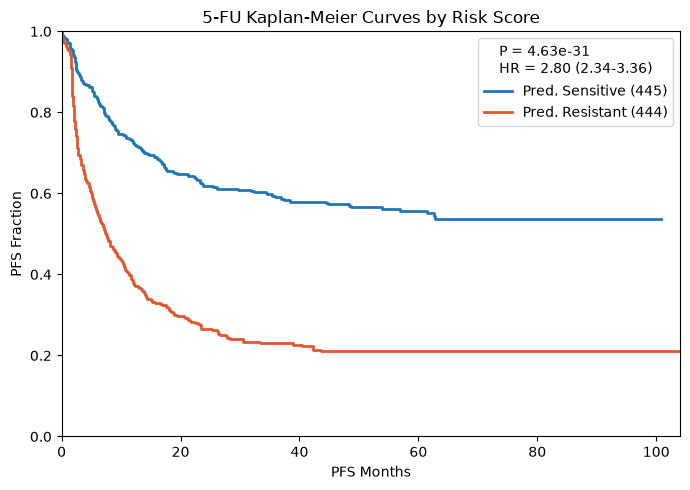

In [80]:
df3 = stratify_by_risk_score(
    survival_table=survival_table,
    drug_name="5-FU",
    output_svg="5-fu_risk_km_full.svg",
)

#### Gemcitabine

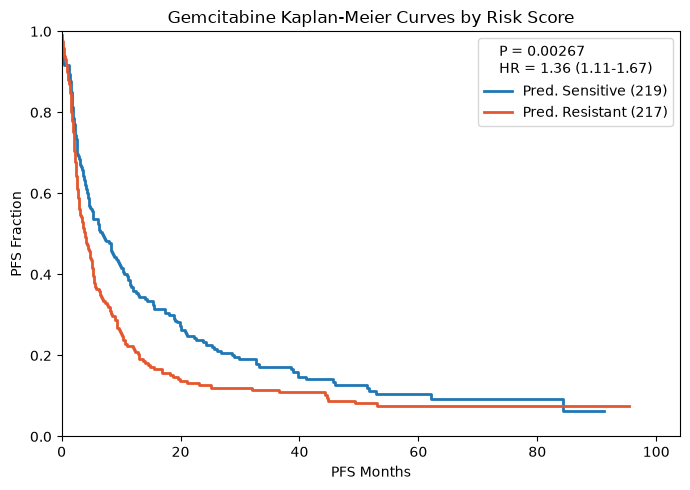

In [83]:
df3 = stratify_by_risk_score(
    survival_table=survival_table,
    drug_name="Gemcitabine",
    output_svg="gemcitabine_risk_km_full.svg",
)

#### Camptothecin 

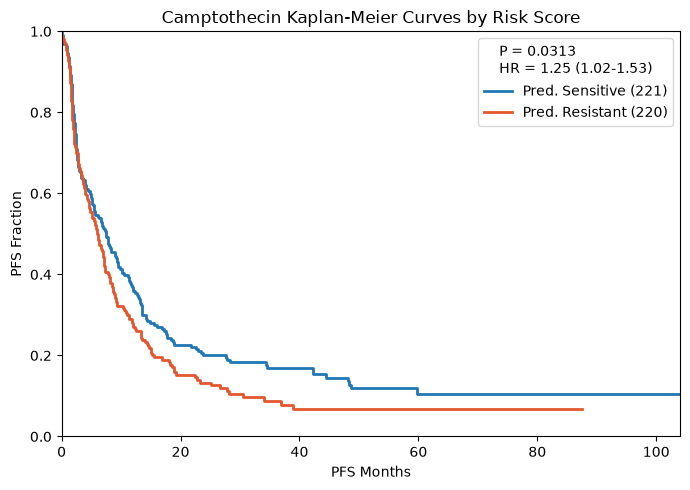

In [82]:
df3 = stratify_by_risk_score(
    survival_table=survival_table,
    drug_name="Camptothecin",
    output_svg="camptothecin_risk_km_full.svg",
)

### Stratify by Risk Score

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

plt.rcParams['svg.fonttype'] = 'none'


def median_surv_time(curve, t_grid):
    below = np.where(curve <= 0.5)[0]
    return t_grid[below[0]] if below.size else t_grid[-1]


def _prepare_drug_cancer_subset(survival_table, patient_table, drug_name, cancer_type):
    surv_df = pd.read_csv(survival_table, sep="\t")
    patient_df = pd.read_csv(patient_table, sep="\t")

    required_surv_cols = {"SAMPLE_ID", "RSI_DRUG", "PFS_MONTHS"}
    missing_surv = required_surv_cols - set(surv_df.columns)
    if missing_surv:
        raise ValueError(f"Missing columns in survival table: {missing_surv}")

    required_patient_cols = {"SAMPLE_ID", "CANCER_TYPE"}
    missing_patient = required_patient_cols - set(patient_df.columns)
    if missing_patient:
        raise ValueError(f"Missing columns in patient table: {missing_patient}")

    merged = surv_df.merge(
        patient_df[["SAMPLE_ID", "CANCER_TYPE"]].drop_duplicates(),
        on="SAMPLE_ID",
        how="left"
    )

    drug_df = merged[merged["RSI_DRUG"] == drug_name].copy()
    if drug_df.empty:
        raise ValueError(f"No rows found for drug: {drug_name}")

    cancer_df = drug_df[drug_df["CANCER_TYPE"] == cancer_type].copy()
    if cancer_df.empty:
        raise ValueError(f"No rows found for drug={drug_name} and cancer_type={cancer_type}")

    dur = pd.to_numeric(cancer_df["PFS_MONTHS"]).to_numpy(dtype=float)
    if "EVENT" in cancer_df.columns:
        ev = pd.to_numeric(cancer_df["EVENT"]).astype(int).to_numpy()
    else:
        ev = cancer_df["PFS_STATUS"].astype(str).str.split(":").str[0].astype(int).to_numpy()

    return merged, drug_df, cancer_df, dur, ev


def _compute_hazard_ratio(dur, ev, sensitive_mask, resistant_mask):
    group = np.full(len(dur), np.nan)
    group[sensitive_mask] = 0
    group[resistant_mask] = 1

    cox_df = pd.DataFrame({
        "PFS_MONTHS": pd.to_numeric(dur, errors="coerce"),
        "EVENT": pd.to_numeric(ev, errors="coerce"),
        "predicted_resistant": group,
    }).dropna()

    if cox_df["predicted_resistant"].nunique() < 2:
        return np.nan, np.nan, np.nan

    try:
        cph = CoxPHFitter()
        cph.fit(cox_df, duration_col="PFS_MONTHS", event_col="EVENT")
        hr = float(np.exp(cph.params_["predicted_resistant"]))
        hr_lower = float(np.exp(cph.confidence_intervals_.loc["predicted_resistant"].iloc[0]))
        hr_upper = float(np.exp(cph.confidence_intervals_.loc["predicted_resistant"].iloc[1]))
        return hr, hr_lower, hr_upper
    except Exception:
        return np.nan, np.nan, np.nan


def _plot_drug_cancer_km(dur, ev, sensitive_mask, resistant_mask, title, ylabel, output_svg=None):
    p_value = logrank_test(
        dur[resistant_mask], dur[sensitive_mask],
        event_observed_A=ev[resistant_mask],
        event_observed_B=ev[sensitive_mask]
    ).p_value

    hr, hr_lower, hr_upper = _compute_hazard_ratio(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive_mask,
        resistant_mask=resistant_mask,
    )

    sensitive_color = "#1f77b4"
    resistant_color = "#e4572e"

    kmf = KaplanMeierFitter()
    plt.figure(figsize=(7, 5))

    kmf.fit(
        dur[sensitive_mask],
        ev[sensitive_mask],
        label=f"Pred. Sensitive ({sensitive_mask.sum()})"
    )
    ax = kmf.plot_survival_function(ci_show=False, color=sensitive_color, linewidth=2.0)

    kmf.fit(
        dur[resistant_mask],
        ev[resistant_mask],
        label=f"Pred. Resistant ({resistant_mask.sum()})"
    )
    kmf.plot_survival_function(ci_show=False, color=resistant_color, linewidth=2.0, ax=ax)

    plt.title(title)
    plt.xlabel("PFS Months")
    plt.ylabel(ylabel)
    plt.grid(False)

    plt.xlim(0, 104)
    plt.xticks(np.arange(0, 101, 20))
    plt.ylim(0.0, 1.0)
    plt.yticks(np.arange(0.0, 1.01, 0.2))

    if np.isfinite(hr):
        legend_title = f"P = {p_value:.3g}\nHR = {hr:.2f} ({hr_lower:.2f}-{hr_upper:.2f})"
    else:
        legend_title = f"P = {p_value:.3g}\nHR = nan"

    plt.legend(title=legend_title)
    plt.tight_layout()

    if output_svg is not None:
        plt.savefig(output_svg, format="svg", bbox_inches="tight")

    plt.show()
    return p_value, hr, hr_lower, hr_upper


def stratify_drug_cancer_by_predicted_median(
    survival_table,
    patient_table,
    drug_name,
    cancer_type,
    threshold_scope="drug_only",
    output_svg=None,
):
    merged, drug_df, cancer_df, dur, ev = _prepare_drug_cancer_subset(
        survival_table, patient_table, drug_name, cancer_type
    )

    time_cols = [c for c in merged.columns if c.startswith("time_")]
    if not time_cols:
        raise ValueError("No survival probability columns found.")

    times = np.array([float(c.replace("time_", "")) for c in time_cols])
    order = np.argsort(times)
    times = times[order]
    time_cols = [time_cols[i] for i in order]

    if threshold_scope == "drug_only":
        threshold_df = drug_df
    elif threshold_scope == "drug_and_cancer":
        threshold_df = cancer_df
    else:
        raise ValueError("threshold_scope must be 'drug_only' or 'drug_and_cancer'")

    S_threshold = threshold_df[time_cols].to_numpy(dtype=float)
    med_surv_threshold = np.array([
        median_surv_time(S_threshold[i], times) for i in range(S_threshold.shape[0])
    ])
    cut = np.median(med_surv_threshold)

    S_eval = cancer_df[time_cols].to_numpy(dtype=float)
    med_surv_eval = np.array([
        median_surv_time(S_eval[i], times) for i in range(S_eval.shape[0])
    ])

    sensitive = med_surv_eval >= cut
    resistant = ~sensitive

    scope_label = "all drug-treated patients" if threshold_scope == "drug_only" else "drug + cancer subset"
    p_value, hr, hr_lower, hr_upper = _plot_drug_cancer_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} / {cancer_type}\nThreshold from {scope_label}",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = cancer_df.copy()
    out_df["predicted_median_survival"] = med_surv_eval
    out_df["median_cutoff_used"] = cut
    out_df["predicted_group"] = np.where(sensitive, "sensitive", "resistant")
    out_df["threshold_scope"] = threshold_scope
    out_df["hazard_ratio_resistant_vs_sensitive"] = hr

    return {
        "data": out_df,
        "p_value": p_value,
        "hazard_ratio": hr,
        "hazard_ratio_ci_lower": hr_lower,
        "hazard_ratio_ci_upper": hr_upper,
    }


def stratify_drug_cancer_by_risk_score(
    survival_table,
    patient_table,
    drug_name,
    cancer_type,
    threshold_scope="drug_only",
    output_svg=None,
):
    merged, drug_df, cancer_df, dur, ev = _prepare_drug_cancer_subset(
        survival_table, patient_table, drug_name, cancer_type
    )

    if "risk_score" not in merged.columns:
        raise ValueError("Missing column 'risk_score' in survival table.")

    if threshold_scope == "drug_only":
        threshold_df = drug_df
    elif threshold_scope == "drug_and_cancer":
        threshold_df = cancer_df
    else:
        raise ValueError("threshold_scope must be 'drug_only' or 'drug_and_cancer'")

    risk_threshold = pd.to_numeric(threshold_df["risk_score"]).to_numpy(dtype=float)
    cut = np.median(risk_threshold)

    risk_eval = pd.to_numeric(cancer_df["risk_score"]).to_numpy(dtype=float)

    sensitive = risk_eval <= cut
    resistant = ~sensitive

    scope_label = "all drug-treated patients" if threshold_scope == "drug_only" else "drug + cancer subset"
    p_value, hr, hr_lower, hr_upper = _plot_drug_cancer_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} / {cancer_type}\nRisk threshold from {scope_label}",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = cancer_df.copy()
    out_df["risk_cutoff_used"] = cut
    out_df["risk_group"] = np.where(sensitive, "sensitive", "resistant")
    out_df["threshold_scope"] = threshold_scope
    out_df["hazard_ratio_resistant_vs_sensitive"] = hr

    return {
        "data": out_df,
        "p_value": p_value,
        "hazard_ratio": hr,
        "hazard_ratio_ci_lower": hr_lower,
        "hazard_ratio_ci_upper": hr_upper,
    }


def stratify_drug_cancer_by_predicted_auc(
    survival_table,
    patient_table,
    drug_name,
    cancer_type,
    threshold_scope="drug_only",
    output_svg=None,
):
    merged, drug_df, cancer_df, dur, ev = _prepare_drug_cancer_subset(
        survival_table, patient_table, drug_name, cancer_type
    )

    if "predicted_auc" not in merged.columns:
        raise ValueError("Missing column 'predicted_auc' in survival table.")

    if threshold_scope == "drug_only":
        threshold_df = drug_df
    elif threshold_scope == "drug_and_cancer":
        threshold_df = cancer_df
    else:
        raise ValueError("threshold_scope must be 'drug_only' or 'drug_and_cancer'")

    auc_threshold = pd.to_numeric(threshold_df["predicted_auc"]).to_numpy(dtype=float)
    cut = np.median(auc_threshold)

    auc_eval = pd.to_numeric(cancer_df["predicted_auc"]).to_numpy(dtype=float)

    sensitive = auc_eval <= cut
    resistant = ~sensitive

    scope_label = "all drug-treated patients" if threshold_scope == "drug_only" else "drug + cancer subset"
    p_value, hr, hr_lower, hr_upper = _plot_drug_cancer_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} / {cancer_type}\nAUC threshold from {scope_label}",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = cancer_df.copy()
    out_df["auc_cutoff_used"] = cut
    out_df["auc_group"] = np.where(sensitive, "sensitive", "resistant")
    out_df["threshold_scope"] = threshold_scope
    out_df["hazard_ratio_resistant_vs_sensitive"] = hr

    return {
        "data": out_df,
        "p_value": p_value,
        "hazard_ratio": hr,
        "hazard_ratio_ci_lower": hr_lower,
        "hazard_ratio_ci_upper": hr_upper,
    }


def stratify_drug_cancer_by_risk_score_threshold(
    survival_table,
    patient_table,
    drug_name,
    cancer_type,
    output_svg=None,
):
    merged, drug_df, cancer_df, dur, ev = _prepare_drug_cancer_subset(
        survival_table, patient_table, drug_name, cancer_type
    )

    required_cols = {"risk_score", "risk_cutoff", "predicted_group"}
    missing = required_cols - set(merged.columns)
    if missing:
        raise ValueError(
            f"Missing thresholded risk-score columns in survival table: {missing}"
        )

    risk = pd.to_numeric(cancer_df["risk_score"]).to_numpy(dtype=float)
    cut = pd.to_numeric(cancer_df["risk_cutoff"]).to_numpy(dtype=float)

    if np.isnan(cut).any():
        raise ValueError("Found missing values in 'risk_cutoff'.")

    sensitive = (cancer_df["predicted_group"].astype(str) == "sensitive").to_numpy()
    resistant = (cancer_df["predicted_group"].astype(str) == "resistant").to_numpy()

    if not np.all((risk <= cut) == sensitive):
        print("Warning: predicted_group is not perfectly consistent with risk_score <= risk_cutoff for all rows.")

    p_value, hr, hr_lower, hr_upper = _plot_drug_cancer_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} / {cancer_type}\nValidation-derived risk threshold",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = cancer_df.copy()
    out_df["hazard_ratio_resistant_vs_sensitive"] = hr

    return {
        "data": out_df,
        "p_value": p_value,
        "hazard_ratio": hr,
        "hazard_ratio_ci_lower": hr_lower,
        "hazard_ratio_ci_upper": hr_upper,
    }


### Stratify by Risk Median

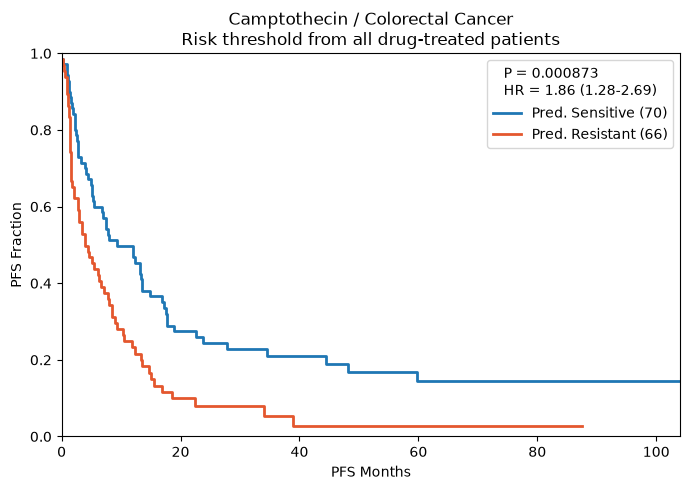

In [7]:
df1 = stratify_drug_cancer_by_risk_score(
    survival_table=survival_table,
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
    drug_name="Camptothecin", # Irinotecan, camptothecin analog
    cancer_type="Colorectal Cancer",
    threshold_scope="drug_only",
    #output_svg="Gemcitabine_pancreatic_drug_and_cancer.svg",
)

## Analyze Performance with C-Index, Compare Against ElasticNet

#### C-Index for Drug+Cancer Type Cohort

In [67]:
import csv
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines.utils import concordance_index
from scipy.stats import wilcoxon
from sklearn.base import clone
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["svg.fonttype"] = "none"

TASKS = [
    ("5-FU", "Colorectal Cancer", "5-FU\nColorectal"),
    ("5-FU", "Pancreatic Cancer", "5-FU\nPancreatic"),
    ("Camptothecin", "Colorectal Cancer", "Camptothecin\nColorectal"),
    ("Gemcitabine", "Pancreatic Cancer", "Gemcitabine\nPancreatic"),
    #("5-FU", "Breast Cancer", "5-FU\nBreast"),
    #("Camptothecin", "Pancreatic Cancer", "Pancreatic\nColorectal"),
    #("Gemcitabine", "Pancreatic Cancer", "Gemcitabine\nPancreatic"),
    #("Gemcitabine", "Non-Small Cell Lung Cancer", "Gemcitabine\nLung"),
    #("Cisplatin", "Non-Small Cell Lung Cancer", "Cisplatin\nLung"),
    #("Doxorubicin", "Breast Cancer", "Doxorubicin\nBreast"),
    #("Methotrexate", "Breast Cancer", "Methotrexate\nBreast"),
]

smiles_to_name = {
    "C1=C(C(=O)NC(=O)N1)F": "5-FU",
    "C1=CN(C(=O)N=C1N)[C@H]2C([C@@H]([C@H](O2)CO)O)(F)F": "Gemcitabine",
    "C1C2CC3CC1CC(C2)(C3)C4=C(C=CC(=C4)C5=CC6=C(C=C5)C=C(C=C6)C(=O)O)O": "CD437",
    "C1CC1C(=O)N2CCN(CC2)C(=O)C3=C(C=CC(=C3)CC4=NNC(=O)C5=CC=CC=C54)F": "Ceralasertib",
    "CC(C)(C1=NC(=CC=C1)N2C3=NC(=NC=C3C(=O)N2CC=C)NC4=CC=C(C=C4)N5CCN(CC5)C)O": "MK-1775",
    "CC1=C(N=C(N=C1N)[C@H](CC(=O)N)NC[C@@H](C(=O)N)N)C(=O)N[C@@H]([C@H](C2=CN=CN2)O[C@H]3[C@H]([C@H]([C@@H]([C@@H](O3)CO)O)O)O[C@@H]4[C@H]([C@H]([C@@H]([C@H](O4)CO)O)OC(=O)N)O)C(=O)N[C@H](C)[C@H]([C@H](C)C(=O)N[C@@H]([C@@H](C)O)C(=O)NCCC5=NC(=CS5)C6=NC(=CS6)C(=O)NCCC[S+](C)C)O": "Bleomycin-a2",
    "CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3=C2)O": "Camptothecin",
    "CN(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C3)C(=O)N[C@@H](CCC(=O)O)C(=O)O": "Methotrexate",
    "C[C@@H]1COCCN1C2=NC(=NC(=C2)C3(CC3)[S@](=N)(=O)C)C4=C5C=CNC5=NC=C4": "Olaparib",
    "C[C@@H]1OC[C@@H]2[C@@H](O1)[C@@H]([C@H]([C@@H](O2)O[C@H]3[C@H]4COC(=O)[C@@H]4[C@@H](C5=CC6=C(C=C35)OCO6)C7=CC(=C(C(=C7)OC)O)OC)O)O": "Etoposide",
    "C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC3=C2C(=C4C(=C3O)C(=O)C5=C(C4=O)C(=CC=C5)OC)O)(C(=O)CO)O)N)O": "Doxorubicin",
    "N.N.[Cl-].[Cl-].[Pt+2]": "Cisplatin",
}


def encode_event(series):
    return series.astype(str).str.split(":").str[0].astype(int)


def safe_cindex(times, events, score, use_event_observed=True):
    times = np.asarray(times, dtype=float)
    events = np.asarray(events, dtype=int)
    score = np.asarray(score, dtype=float)

    mask = np.isfinite(times) & np.isfinite(score)
    if use_event_observed:
        mask &= np.isfinite(events)

    times = times[mask]
    events = events[mask]
    score = score[mask]

    if len(times) < 2:
        return np.nan
    if np.allclose(score, score[0]):
        return 0.5

    try:
        if use_event_observed:
            return float(concordance_index(times, -score, event_observed=events))
        return float(concordance_index(times, -score))
    except ZeroDivisionError:
        return np.nan


def paired_wilcoxon_greater(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    if len(a) < 2:
        return np.nan

    diffs = a - b
    if np.allclose(diffs, 0):
        return 1.0

    try:
        _, p = wilcoxon(a, b, alternative="greater", zero_method="wilcox")
        return float(p)
    except ValueError:
        return 1.0


def add_sig_bracket(ax, x1, x2, y, h, text="*", lw=1.2):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        linewidth=lw,
        clip_on=False,
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        color="black",
        clip_on=False,
        zorder=5,
    )


def transform_cindex_axis(y):
    y = np.asarray(y, dtype=float)
    out = y.copy()

    low = y < 0.3
    high = ~low

    out[low] = y[low] / 3.0
    out[high] = y[high] - 0.2

    return out


def load_patient_table(path):
    df = pd.read_csv(path, sep="\t")
    return df[["SAMPLE_ID", "CANCER_TYPE"]].drop_duplicates()


def load_eval_table(path, patient_meta):
    df = pd.read_csv(path, sep="\t")
    df["EVENT"] = encode_event(df["PFS_STATUS"])
    df["PFS_MONTHS"] = pd.to_numeric(df["PFS_MONTHS"], errors="coerce")
    df = df.merge(patient_meta, on="SAMPLE_ID", how="left")
    return df


def load_index_map(path):
    mapping = {}
    with open(path, newline="") as handle:
        reader = csv.reader(handle, delimiter="\t")
        for row in reader:
            if not row:
                continue
            if len(row) >= 2 and row[0].strip().lower() == "index" and row[1].strip().lower() == "sample":
                continue
            mapping[row[1]] = int(row[0])
    return mapping


def load_binary_matrix(path, n_rows=None):
    rows = []

    with open(path, newline="") as handle:
        reader = csv.reader(handle)
        for row in reader:
            if not row:
                continue

            if len(row) == 1:
                values = row[0].strip().strip('"').split(",")
            else:
                values = [v.strip().strip('"') for v in row]

            values = [v for v in values if v != ""]
            rows.append([int(v) for v in values])

    arr = np.asarray(rows, dtype=np.float32)

    if n_rows is not None and arr.shape[0] != n_rows:
        raise ValueError(f"{path}: expected {n_rows} rows, got {arr.shape[0]}")

    return arr


def load_cell_index(cell_index_file):
    df = pd.read_csv(cell_index_file, sep="\t", header=None, engine="python").iloc[:, :2]
    df.columns = ["index", "cell"]
    cell_to_idx = dict(zip(df["cell"].astype(str), df["index"].astype(int)))
    idx_to_cell = dict(zip(df["index"].astype(int), df["cell"].astype(str)))
    return cell_to_idx, idx_to_cell


def load_gene_index(gene_index_file):
    df = pd.read_csv(gene_index_file, sep="\t", header=None, engine="python").iloc[:, :2]
    df.columns = ["index", "gene"]
    return dict(zip(df["index"].astype(int), df["gene"].astype(str)))


def build_feature_matrix(cell_index_file, gene_index_file, mut_file, del_file, amp_file):
    cell_to_idx, idx_to_cell = load_cell_index(cell_index_file)
    n_cells = len(cell_to_idx)
    idx_to_gene = load_gene_index(gene_index_file)
    n_genes = len(idx_to_gene)

    x_mut = load_binary_matrix(mut_file, n_rows=n_cells)
    x_del = load_binary_matrix(del_file, n_rows=n_cells)
    x_amp = load_binary_matrix(amp_file, n_rows=n_cells)

    if x_mut.shape[1] != n_genes or x_del.shape[1] != n_genes or x_amp.shape[1] != n_genes:
        raise ValueError("Gene dimension mismatch.")

    x_all = np.concatenate([x_mut, x_del, x_amp], axis=1)
    return x_all, cell_to_idx, idx_to_cell


def load_response_file(path):
    df = pd.read_csv(path, sep="\t", header=None, engine="python").iloc[:, :4]
    df.columns = ["cell", "smiles", "auc", "db"]
    return df


def train_full_elasticnet_models(
    cell_index_file,
    gene_index_file,
    mut_file,
    del_file,
    amp_file,
    train_files,
):
    x_all, cell_to_idx, _ = build_feature_matrix(
        cell_index_file=cell_index_file,
        gene_index_file=gene_index_file,
        mut_file=mut_file,
        del_file=del_file,
        amp_file=amp_file,
    )

    response_frames = [load_response_file(path) for path in train_files]
    response_df = pd.concat(response_frames, ignore_index=True)
    response_df["drug"] = response_df["smiles"].map(smiles_to_name)
    response_df = response_df.dropna(subset=["drug", "auc"])
    response_df = response_df[response_df["cell"].isin(cell_to_idx.keys())].copy()

    base_model = Pipeline(
        steps=[
            ("scaler", StandardScaler(with_mean=True, with_std=True)),
            ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=0)),
        ]
    )

    models = {}
    for drug_name, drug_df in response_df.groupby("drug", sort=True):
        drug_df = drug_df.drop_duplicates(subset=["cell", "auc"]).copy()
        train_idx = [cell_to_idx[cell] for cell in drug_df["cell"].tolist()]
        x_train = x_all[train_idx, :]
        y_train = drug_df["auc"].astype(float).values
        if len(y_train) < 2:
            continue
        model = clone(base_model)
        model.fit(x_train, y_train)
        models[drug_name] = model

    return models


def build_patient_feature_matrix(patient_index_file, patient_mut_file, patient_del_file, patient_amp_file):
    sample_to_idx = load_index_map(patient_index_file)
    n_rows = len(sample_to_idx)

    x_mut = load_binary_matrix(patient_mut_file, n_rows=n_rows)
    x_del = load_binary_matrix(patient_del_file, n_rows=n_rows)
    x_amp = load_binary_matrix(patient_amp_file, n_rows=n_rows)

    x_all = np.concatenate([x_mut, x_del, x_amp], axis=1)
    return x_all, sample_to_idx


def predict_elasticnet_for_table(auc_df, elasticnet_models, patient_x, sample_to_idx):
    df = auc_df.copy()
    preds = []
    for _, row in df.iterrows():
        drug = row["RSI_DRUG"]
        sample = row["SAMPLE_ID"]
        if drug not in elasticnet_models or sample not in sample_to_idx:
            preds.append(np.nan)
            continue
        x = patient_x[sample_to_idx[sample], :].reshape(1, -1)
        preds.append(float(elasticnet_models[drug].predict(x)[0]))
    df["elasticnet_auc"] = preds
    return df


def subset_task(df, drug_name, cancer_type):
    return df[(df["RSI_DRUG"] == drug_name) & (df["CANCER_TYPE"] == cancer_type)].copy()


def cindex_by_fold(df, score_col, use_event_observed=True):
    values = []
    for fold, fold_df in sorted(df.groupby("fold"), key=lambda x: str(x[0])):
        cidx = safe_cindex(
            fold_df["PFS_MONTHS"],
            fold_df["EVENT"],
            fold_df[score_col],
            use_event_observed=use_event_observed,
        )
        if np.isfinite(cidx):
            values.append(float(cidx))
    return values


def cindex_pooled(df, score_col, use_event_observed=True):
    return safe_cindex(
        df["PFS_MONTHS"],
        df["EVENT"],
        df[score_col],
        use_event_observed=use_event_observed,
    )


def collect_task_results(risk_df, auc_df, elasticnet_df, evaluation_mode="per_fold", use_event_observed=True):
    labels = []
    drpt_risk_points = []
    drpt_auc_points = []
    elasticnet_points = []
    drpt_risk_heights = []
    drpt_auc_heights = []
    elasticnet_heights = []

    for drug_name, cancer_type, label in TASKS:
        labels.append(label)

        risk_task = subset_task(risk_df, drug_name, cancer_type)
        auc_task = subset_task(auc_df, drug_name, cancer_type)
        en_task = subset_task(elasticnet_df, drug_name, cancer_type)

        if evaluation_mode == "per_fold":
            risk_vals = cindex_by_fold(risk_task, "risk_score", use_event_observed=use_event_observed)
            auc_vals = cindex_by_fold(auc_task, "predicted_auc", use_event_observed=use_event_observed)
            en_vals = cindex_by_fold(en_task, "elasticnet_auc", use_event_observed=use_event_observed)

            drpt_risk_points.append(risk_vals)
            drpt_auc_points.append(auc_vals)
            elasticnet_points.append(en_vals)

            drpt_risk_heights.append(float(np.nanmean(risk_vals)) if risk_vals else np.nan)
            drpt_auc_heights.append(float(np.nanmean(auc_vals)) if auc_vals else np.nan)
            elasticnet_heights.append(float(np.nanmean(en_vals)) if en_vals else np.nan)
        else:
            risk_val = cindex_pooled(risk_task, "risk_score", use_event_observed=use_event_observed)
            auc_val = cindex_pooled(auc_task, "predicted_auc", use_event_observed=use_event_observed)
            en_val = cindex_pooled(en_task, "elasticnet_auc", use_event_observed=use_event_observed)

            drpt_risk_points.append([])
            drpt_auc_points.append([])
            elasticnet_points.append([])

            drpt_risk_heights.append(risk_val)
            drpt_auc_heights.append(auc_val)
            elasticnet_heights.append(en_val)

    return (
        labels,
        drpt_risk_points,
        drpt_auc_points,
        elasticnet_points,
        drpt_risk_heights,
        drpt_auc_heights,
        elasticnet_heights,
    )


def summarize_task_pvalues(drpt_risk_points, drpt_auc_points, elasticnet_points, labels):
    rows = []
    for i, label in enumerate(labels):
        a = np.asarray(drpt_risk_points[i], dtype=float)
        b = np.asarray(drpt_auc_points[i], dtype=float)
        c = np.asarray(elasticnet_points[i], dtype=float)

        rows.append({
            "task": label,
            "p_coxph_gt_auc": paired_wilcoxon_greater(a, b),
            "p_coxph_gt_elasticnet": paired_wilcoxon_greater(a, c),
            "p_auc_gt_elasticnet": paired_wilcoxon_greater(b, c),
        })
    return pd.DataFrame(rows)


def plot_cindex_comparison(
    labels,
    drpt_risk_points,
    drpt_auc_points,
    elasticnet_points,
    drpt_risk_heights,
    drpt_auc_heights,
    elasticnet_heights,
    evaluation_mode="per_fold",
    use_event_observed=True,
    output_svg="drpt_vs_auc_vs_elasticnet_cindex_supplementary.svg",
    output_png="drpt_vs_auc_vs_elasticnet_cindex_supplementary.png"
):
    # ------------------------------------------------------------
    # Sort by descending DRPT-CoxPH mean C-index
    # ------------------------------------------------------------
    order = sorted(
        range(len(labels)),
        key=lambda i: (
            -np.inf if not np.isfinite(drpt_risk_heights[i]) else -drpt_risk_heights[i],
            labels[i],
        )
    )

    labels = [labels[i] for i in order]
    drpt_risk_points = [drpt_risk_points[i] for i in order]
    drpt_auc_points = [drpt_auc_points[i] for i in order]
    elasticnet_points = [elasticnet_points[i] for i in order]
    drpt_risk_heights = [drpt_risk_heights[i] for i in order]
    drpt_auc_heights = [drpt_auc_heights[i] for i in order]
    elasticnet_heights = [elasticnet_heights[i] for i in order]

    group_spacing = 0.32
    x = np.arange(len(labels)) * group_spacing
    width = 0.07

    x_risk = x - width
    x_auc = x
    x_en = x + width

    fig, ax = plt.subplots(figsize=(6.5, 6))

    light_grey = "#d9d9d9"
    light_blue = "#8ecae6"
    orange = "#f4a261"
    edge = "#355070"

    risk_h_t = transform_cindex_axis(np.asarray(drpt_risk_heights, dtype=float))
    auc_h_t = transform_cindex_axis(np.asarray(drpt_auc_heights, dtype=float))
    en_h_t = transform_cindex_axis(np.asarray(elasticnet_heights, dtype=float))

    ax.bar(
        x_risk, risk_h_t, width,
        label="DRPT-CoxPH",
        color=light_grey,
        edgecolor=edge,
        linewidth=0.6,
        zorder=2,
    )
    ax.bar(
        x_auc, auc_h_t, width,
        label="DRPT-AUC",
        color=light_blue,
        edgecolor=edge,
        linewidth=0.6,
        zorder=2,
    )
    ax.bar(
        x_en, en_h_t, width,
        label="ElasticNet",
        color=orange,
        edgecolor=edge,
        linewidth=0.6,
        zorder=2,
    )

    if evaluation_mode == "per_fold":
        for i in range(len(labels)):
            if drpt_risk_points[i]:
                yvals = transform_cindex_axis(np.asarray(drpt_risk_points[i], dtype=float))
                ax.scatter(
                    np.full(len(yvals), x_risk[i]),
                    yvals,
                    color=light_grey,
                    edgecolor=edge,
                    linewidth=0.6,
                    s=28,
                    zorder=3,
                )
            if drpt_auc_points[i]:
                yvals = transform_cindex_axis(np.asarray(drpt_auc_points[i], dtype=float))
                ax.scatter(
                    np.full(len(yvals), x_auc[i]),
                    yvals,
                    color=light_blue,
                    edgecolor=edge,
                    linewidth=0.6,
                    s=28,
                    zorder=3,
                )
            if elasticnet_points[i]:
                yvals = transform_cindex_axis(np.asarray(elasticnet_points[i], dtype=float))
                ax.scatter(
                    np.full(len(yvals), x_en[i]),
                    yvals,
                    color=orange,
                    edgecolor=edge,
                    linewidth=0.6,
                    s=28,
                    zorder=3,
                )

        all_points_raw = []
        for vals in drpt_risk_points + drpt_auc_points + elasticnet_points:
            all_points_raw.extend([v for v in vals if np.isfinite(v)])
        all_points_raw = np.asarray(all_points_raw, dtype=float)

        if all_points_raw.size:
            all_points_t = transform_cindex_axis(all_points_raw)
            yr = np.nanmax(all_points_t) - np.nanmin(all_points_t)
        else:
            yr = 0.1

        if yr == 0:
            yr = 0.1

        pad = 0.03 * yr
        h = 0.025 * yr
        stack_gap = 0.02 * yr

        for i in range(len(labels)):
            a = np.asarray(drpt_risk_points[i], dtype=float)
            b = np.asarray(drpt_auc_points[i], dtype=float)
            c = np.asarray(elasticnet_points[i], dtype=float)

            p_ab = paired_wilcoxon_greater(a, b)
            p_ac = paired_wilcoxon_greater(a, c)
            p_bc = paired_wilcoxon_greater(b, c)

            sig_ab = np.isfinite(p_ab) and p_ab < 0.05
            sig_ac = np.isfinite(p_ac) and p_ac < 0.05
            sig_bc = np.isfinite(p_bc) and p_bc < 0.05

            if not (sig_ab or sig_ac or sig_bc):
                continue

            vals_i = np.concatenate([
                a[np.isfinite(a)] if a.size else np.array([]),
                b[np.isfinite(b)] if b.size else np.array([]),
                c[np.isfinite(c)] if c.size else np.array([]),
            ])
            if vals_i.size == 0:
                continue

            y_top = np.nanmax(transform_cindex_axis(vals_i))
            next_y = y_top + pad

            if sig_ab:
                add_sig_bracket(ax, x_risk[i], x_auc[i], next_y, h, "*")
                next_y = next_y + h + stack_gap

            if sig_ac:
                add_sig_bracket(ax, x_risk[i], x_en[i], next_y, h, "*")
                next_y = next_y + h + stack_gap

            if sig_bc:
                add_sig_bracket(ax, x_auc[i], x_en[i], next_y, h, "*")
                next_y = next_y + h + stack_gap

    ax.axhline(transform_cindex_axis(np.array([0.5]))[0], color="red", linestyle="--", linewidth=1.2, zorder=1)

    tick_vals = np.array([0.0, 0.3, 0.4, 0.5, 0.6, 0.7])
    tick_pos = transform_cindex_axis(tick_vals)

    ax.set_ylabel("C-index", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([])
    ax.tick_params(axis="x", length=4, width=1, direction="out")

    for xi, label in zip(x, labels):
        ax.text(
            xi,
            -0.09,
            label,
            transform=ax.get_xaxis_transform(),
            rotation=None,
            rotation_mode="anchor",
            ha="right",
            va="top",
            fontsize=10,
            clip_on=False,
        )

    ax.set_yticks(tick_pos)
    ax.set_yticklabels([f"{v:.1f}" for v in tick_vals])
    ax.set_ylim(0.0, transform_cindex_axis(np.array([0.7]))[0] + 0.08)
    ax.grid(False)
    ax.legend(
        fontsize=10,
        frameon=False,
        loc="upper right",
        bbox_to_anchor=(1.0, 0.88)
    )
    ax.set_title("")

    y_top_spine = transform_cindex_axis(np.array([0.7]))[0]
    ax.spines["top"].set_position(("data", y_top_spine))
    ax.spines["left"].set_bounds(0.0, y_top_spine)
    ax.spines["right"].set_bounds(0.0, y_top_spine)

    #if use_event_observed:
        #ax.text(
            #0.01, 0.98, "C-index uses event_observed",
            #transform=ax.transAxes,
            #ha="left",
            #va="top",
            #fontsize=9,
        #)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.34)

    if output_svg is not None:
        fig.savefig(output_svg, format="svg", bbox_inches="tight")
    if output_png is not None:
        fig.savefig(output_png, dpi=600, bbox_inches="tight")

    plt.show()

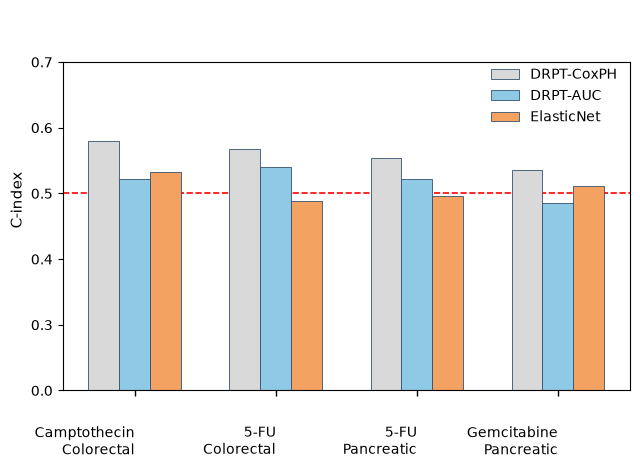

In [68]:
risk_table1 = survival_table

auc_table1 = "msk_drpt_transfer_3_survival_probabilities.tsv"

risk_table = risk_table1
auc_table = auc_table1
patient_table = "data/patients/msk_patients_rsi_drugs.txt"

cell_index_file = "data/cell2ind_av.txt"
gene_index_file = "data/gene2ind_ctg_av.txt"
cell_mut_file = "data/cell2mutation_ctg_av.txt"
cell_del_file = "data/cell2cndeletion_ctg_av.txt"
cell_amp_file = "data/cell2cnamplification_ctg_av.txt"

patient_mut_file = "data/patients/cell2mutation_msk.txt"
patient_del_file = "data/patients/cell2cndeletion_msk.txt"
patient_amp_file = "data/patients/cell2cnamplification_msk.txt"
patient_index_file = "data/patients/patient2ind_msk.txt"

train_files = [f"data/train_splits/full_train_rsi_{i}.txt" for i in range(5)]

use_event_observed = True

patient_meta = load_patient_table(patient_table)
risk_df = load_eval_table(risk_table, patient_meta)
auc_df = load_eval_table(auc_table, patient_meta)

elasticnet_models = train_full_elasticnet_models(
    cell_index_file=cell_index_file,
    gene_index_file=gene_index_file,
    mut_file=cell_mut_file,
    del_file=cell_del_file,
    amp_file=cell_amp_file,
    train_files=train_files,
)

patient_x, patient_sample_to_idx = build_patient_feature_matrix(
    patient_index_file=patient_index_file,
    patient_mut_file=patient_mut_file,
    patient_del_file=patient_del_file,
    patient_amp_file=patient_amp_file,
)

elasticnet_df = predict_elasticnet_for_table(
    auc_df=auc_df,
    elasticnet_models=elasticnet_models,
    patient_x=patient_x,
    sample_to_idx=patient_sample_to_idx,
)

(
    labels,
    drpt_risk_points,
    drpt_auc_points,
    elasticnet_points,
    drpt_risk_heights,
    drpt_auc_heights,
    elasticnet_heights,
) = collect_task_results(
    risk_df=risk_df,
    auc_df=auc_df,
    elasticnet_df=elasticnet_df,
    evaluation_mode="pooled",   # or "pooled"
    use_event_observed=use_event_observed,
)

plot_cindex_comparison(
    labels=labels,
    drpt_risk_points=drpt_risk_points,
    drpt_auc_points=drpt_auc_points,
    elasticnet_points=elasticnet_points,
    drpt_risk_heights=drpt_risk_heights,
    drpt_auc_heights=drpt_auc_heights,
    elasticnet_heights=elasticnet_heights,
    evaluation_mode="pooled",
    use_event_observed=use_event_observed,
    #output_svg="drpt_vs_auc_vs_elasticnet_cindex_pooled.svg",
    #output_png="drpt_vs_auc_vs_elasticnet_cindex_pooled.png"
)

## Show Hazard Rate Comparisons Instead of C-Index


DRPT-CoxPH THRESHOLD-SCOPE SELECTION

                  cohort  coxph_hr_drug_only  coxph_ci_lower_drug_only  coxph_ci_upper_drug_only  coxph_hr_drug_and_cancer  coxph_ci_lower_drug_and_cancer  coxph_ci_upper_drug_and_cancer selected_threshold_scope
        5-FU\nColorectal            1.522169                  1.155145                  2.005808                  1.456702                        1.108586                        1.914133                drug_only
Camptothecin\nColorectal            1.855661                  1.282053                  2.685910                  1.868035                        1.288128                        2.709014          drug_and_cancer
 Gemcitabine\nPancreatic            1.378220                  1.102344                  1.723137                  1.297824                        1.039067                        1.621020                drug_only
        5-FU\nPancreatic            1.220213                  0.913676                  1.629592                 

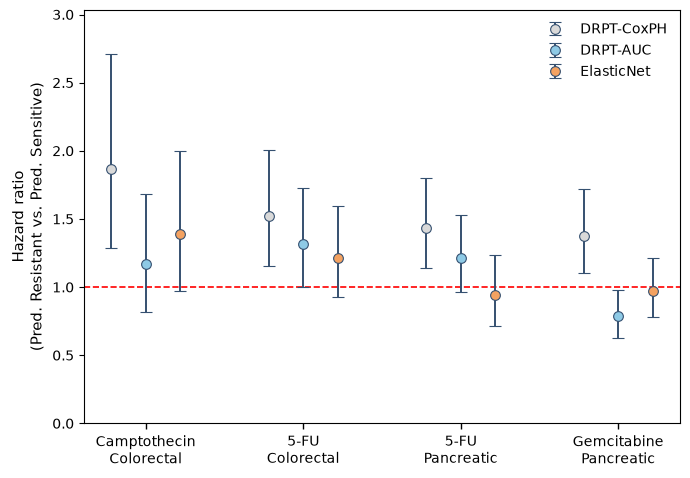

In [53]:
# ============================================================
# HAZARD-RATIO MODEL COMPARISON
# AUTOMATIC THRESHOLD-SCOPE SELECTION
# ============================================================
#
# For EACH drug + cancer cohort:
#
#   1. Compute DRPT-CoxPH HR using:
#
#          A. "drug_only"
#          B. "drug_and_cancer"
#
#   2. Select whichever threshold scope produces the larger
#      DRPT-CoxPH hazard ratio.
#
#   3. Use that SAME selected threshold scope for:
#
#          DRPT-AUC
#          ElasticNet
#
# Therefore, threshold-scope selection is determined ONLY by
# DRPT-CoxPH.
#
# Hazard ratio definition:
#
#       HR = hazard(predicted resistant)
#            ---------------------------
#            hazard(predicted sensitive)
#
# Patients are stratified as:
#
#       sensitive = score <= median threshold
#       resistant = score > median threshold
#
# The Cox model is:
#
#       PFS ~ predicted_resistant
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter


plt.rcParams["svg.fonttype"] = "none"


# ============================================================
# EDIT THE DRUG + CANCER COHORTS HERE
# ============================================================

TASKS = [
    ("5-FU", "Colorectal Cancer", "5-FU\nColorectal"),
    ("Camptothecin", "Colorectal Cancer", "Camptothecin\nColorectal"),
    ("Gemcitabine", "Pancreatic Cancer", "Gemcitabine\nPancreatic"),
    ("5-FU", "Pancreatic Cancer", "5-FU\nPancreatic"),
    #("Gemcitabine", "Non-Small Cell Lung Cancer", "Gemcitabine\nLung"),
    # ("5-FU", "Breast Cancer", "5-FU\nBreast"),
    # ("Doxorubicin", "Breast Cancer", "Doxorubicin\nBreast"),
    # ("Methotrexate", "Breast Cancer", "Methotrexate\nBreast"),
]


# ============================================================
# MODEL DEFINITIONS
# ============================================================

HR_MODEL_SPECS = [
    {
        "model": "DRPT-CoxPH",
        "score_col": "risk_score",
        "color": "#d9d9d9",
    },
    {
        "model": "DRPT-AUC",
        "score_col": "predicted_auc",
        "color": "#8ecae6",
    },
    {
        "model": "ElasticNet",
        "score_col": "elasticnet_auc",
        "color": "#f4a261",
    },
]


# ============================================================
# KM-STYLE HAZARD-RATIO CALCULATION
# ============================================================

def compute_hazard_ratio_binary_groups(
    dur,
    ev,
    sensitive_mask,
    resistant_mask,
):
    """
    Compute resistant-vs-sensitive hazard ratio using the same
    CoxPH formulation as the Kaplan-Meier code.

    predicted_resistant:
        sensitive = 0
        resistant = 1

    HR > 1 means greater progression hazard in the
    predicted-resistant group.
    """

    group = np.full(
        len(dur),
        np.nan,
    )

    group[sensitive_mask] = 0
    group[resistant_mask] = 1

    cox_df = pd.DataFrame(
        {
            "PFS_MONTHS": pd.to_numeric(
                dur,
                errors="coerce",
            ),
            "EVENT": pd.to_numeric(
                ev,
                errors="coerce",
            ),
            "predicted_resistant": group,
        }
    ).dropna()

    if (
        cox_df["predicted_resistant"]
        .nunique()
        < 2
    ):
        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )

    try:
        cph = CoxPHFitter()

        cph.fit(
            cox_df,
            duration_col="PFS_MONTHS",
            event_col="EVENT",
        )

        hr = float(
            np.exp(
                cph.params_[
                    "predicted_resistant"
                ]
            )
        )

        hr_lower = float(
            np.exp(
                cph.confidence_intervals_
                .loc["predicted_resistant"]
                .iloc[0]
            )
        )

        hr_upper = float(
            np.exp(
                cph.confidence_intervals_
                .loc["predicted_resistant"]
                .iloc[1]
            )
        )

        p_value = float(
            cph.summary.loc[
                "predicted_resistant",
                "p",
            ]
        )

        return (
            hr,
            hr_lower,
            hr_upper,
            p_value,
        )

    except Exception as exc:
        print(
            "Cox model failed:",
            type(exc).__name__,
            str(exc),
        )

        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )


# ============================================================
# PREPARE MODEL TABLE
# ============================================================

def prepare_hr_model_table(
    df,
    score_col,
):
    """
    Validate and prepare a patient-level prediction table.
    """

    required_columns = {
        "SAMPLE_ID",
        "RSI_DRUG",
        "CANCER_TYPE",
        "PFS_MONTHS",
        "EVENT",
        score_col,
    }

    missing_columns = (
        required_columns
        - set(df.columns)
    )

    if missing_columns:
        raise ValueError(
            f"Missing columns for {score_col}: "
            f"{missing_columns}"
        )

    out = df.copy()

    out["PFS_MONTHS"] = pd.to_numeric(
        out["PFS_MONTHS"],
        errors="coerce",
    )

    out["EVENT"] = pd.to_numeric(
        out["EVENT"],
        errors="coerce",
    )

    out[score_col] = pd.to_numeric(
        out[score_col],
        errors="coerce",
    )

    return out


# ============================================================
# COMPUTE HR FOR ONE MODEL + ONE COHORT + ONE THRESHOLD SCOPE
# ============================================================

def compute_model_cohort_hr(
    df,
    score_col,
    drug_name,
    cancer_type,
    threshold_scope,
):
    """
    Compute median-stratified resistant-vs-sensitive HR for one
    model, one cohort, and one threshold scope.

    threshold_scope:

        "drug_only"
            Median score among all patients receiving the drug.

        "drug_and_cancer"
            Median score within the selected drug + cancer cohort.
    """

    if threshold_scope not in {
        "drug_only",
        "drug_and_cancer",
    }:
        raise ValueError(
            "threshold_scope must be "
            "'drug_only' or 'drug_and_cancer'"
        )

    df = prepare_hr_model_table(
        df=df,
        score_col=score_col,
    )

    # --------------------------------------------------------
    # All patients treated with this drug
    # --------------------------------------------------------

    drug_df = df[
        df["RSI_DRUG"]
        == drug_name
    ].copy()

    if drug_df.empty:
        raise ValueError(
            f"No patients found for drug: {drug_name}"
        )

    # --------------------------------------------------------
    # Selected drug + cancer cohort
    # --------------------------------------------------------

    cancer_df = drug_df[
        drug_df["CANCER_TYPE"]
        == cancer_type
    ].copy()

    if cancer_df.empty:
        raise ValueError(
            f"No patients found for "
            f"{drug_name} + {cancer_type}"
        )

    # --------------------------------------------------------
    # Select threshold population
    # --------------------------------------------------------

    if threshold_scope == "drug_only":
        threshold_df = drug_df

    else:
        threshold_df = cancer_df

    # --------------------------------------------------------
    # Calculate median threshold
    # --------------------------------------------------------

    threshold_scores = pd.to_numeric(
        threshold_df[score_col],
        errors="coerce",
    ).to_numpy(dtype=float)

    threshold_scores = threshold_scores[
        np.isfinite(threshold_scores)
    ]

    if len(threshold_scores) == 0:
        raise ValueError(
            f"No valid {score_col} values available "
            f"for threshold calculation."
        )

    cutoff = float(
        np.median(
            threshold_scores
        )
    )

    # --------------------------------------------------------
    # Evaluation cohort data
    # --------------------------------------------------------

    eval_score = pd.to_numeric(
        cancer_df[score_col],
        errors="coerce",
    ).to_numpy(dtype=float)

    dur = pd.to_numeric(
        cancer_df["PFS_MONTHS"],
        errors="coerce",
    ).to_numpy(dtype=float)

    ev = pd.to_numeric(
        cancer_df["EVENT"],
        errors="coerce",
    ).to_numpy(dtype=float)

    valid = (
        np.isfinite(eval_score)
        & np.isfinite(dur)
        & np.isfinite(ev)
    )

    eval_score = eval_score[
        valid
    ]

    dur = dur[
        valid
    ]

    ev = ev[
        valid
    ].astype(int)

    # --------------------------------------------------------
    # EXACT KM-style median stratification
    # --------------------------------------------------------

    sensitive_mask = (
        eval_score
        <= cutoff
    )

    resistant_mask = (
        eval_score
        > cutoff
    )

    # --------------------------------------------------------
    # Compute HR
    # --------------------------------------------------------

    (
        hr,
        hr_lower,
        hr_upper,
        p_value,
    ) = compute_hazard_ratio_binary_groups(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive_mask,
        resistant_mask=resistant_mask,
    )

    return {
        "hazard_ratio": hr,
        "ci_lower": hr_lower,
        "ci_upper": hr_upper,
        "p_value": p_value,

        "cutoff": cutoff,

        "n_total": int(
            len(eval_score)
        ),

        "n_sensitive": int(
            sensitive_mask.sum()
        ),

        "n_resistant": int(
            resistant_mask.sum()
        ),

        "n_events": int(
            ev.sum()
        ),
    }


# ============================================================
# CHOOSE BEST THRESHOLD SCOPE USING DRPT-CoxPH ONLY
# ============================================================

def choose_best_coxph_threshold_scope(
    risk_df,
    drug_name,
    cancer_type,
):
    """
    Evaluate DRPT-CoxPH under BOTH threshold strategies and select
    the one producing the larger hazard ratio.

    Importantly, DRPT-AUC and ElasticNet DO NOT influence this
    decision.
    """

    drug_only_result = compute_model_cohort_hr(
        df=risk_df,
        score_col="risk_score",
        drug_name=drug_name,
        cancer_type=cancer_type,
        threshold_scope="drug_only",
    )

    drug_cancer_result = compute_model_cohort_hr(
        df=risk_df,
        score_col="risk_score",
        drug_name=drug_name,
        cancer_type=cancer_type,
        threshold_scope="drug_and_cancer",
    )

    hr_drug_only = (
        drug_only_result[
            "hazard_ratio"
        ]
    )

    hr_drug_cancer = (
        drug_cancer_result[
            "hazard_ratio"
        ]
    )

    # --------------------------------------------------------
    # Handle missing HRs
    # --------------------------------------------------------

    drug_only_valid = (
        np.isfinite(
            hr_drug_only
        )
    )

    drug_cancer_valid = (
        np.isfinite(
            hr_drug_cancer
        )
    )

    if (
        not drug_only_valid
        and not drug_cancer_valid
    ):
        return {
            "selected_scope": None,
            "selected_result": None,
            "drug_only_result": drug_only_result,
            "drug_and_cancer_result": drug_cancer_result,
        }

    if (
        drug_only_valid
        and not drug_cancer_valid
    ):
        selected_scope = (
            "drug_only"
        )

        selected_result = (
            drug_only_result
        )

    elif (
        drug_cancer_valid
        and not drug_only_valid
    ):
        selected_scope = (
            "drug_and_cancer"
        )

        selected_result = (
            drug_cancer_result
        )

    else:

        # ----------------------------------------------------
        # Select the larger HR.
        #
        # If the HRs are exactly tied, prefer drug_only simply
        # to make the behavior deterministic.
        # ----------------------------------------------------

        if (
            hr_drug_only
            >= hr_drug_cancer
        ):
            selected_scope = (
                "drug_only"
            )

            selected_result = (
                drug_only_result
            )

        else:
            selected_scope = (
                "drug_and_cancer"
            )

            selected_result = (
                drug_cancer_result
            )

    return {
        "selected_scope": selected_scope,
        "selected_result": selected_result,

        "drug_only_result": (
            drug_only_result
        ),

        "drug_and_cancer_result": (
            drug_cancer_result
        ),
    }


# ============================================================
# COMPUTE ALL COMPARISON RESULTS
# ============================================================

def collect_hr_comparison_results(
    risk_df,
    auc_df,
    elasticnet_df,
    tasks,
):
    """
    For each drug + cancer cohort:

      1. Evaluate DRPT-CoxPH using both possible threshold scopes.
      2. Select the scope producing the larger DRPT-CoxPH HR.
      3. Use that exact same scope for DRPT-AUC and ElasticNet.
    """

    model_tables = {
        "DRPT-CoxPH": risk_df,
        "DRPT-AUC": auc_df,
        "ElasticNet": elasticnet_df,
    }

    rows = []

    scope_selection_rows = []

    for task_order, (
        drug_name,
        cancer_type,
        plot_label,
    ) in enumerate(tasks):

        # ====================================================
        # STEP 1:
        # Determine best threshold scope from DRPT-CoxPH
        # ====================================================

        scope_selection = (
            choose_best_coxph_threshold_scope(
                risk_df=risk_df,
                drug_name=drug_name,
                cancer_type=cancer_type,
            )
        )

        selected_scope = (
            scope_selection[
                "selected_scope"
            ]
        )

        drug_only_result = (
            scope_selection[
                "drug_only_result"
            ]
        )

        drug_cancer_result = (
            scope_selection[
                "drug_and_cancer_result"
            ]
        )

        scope_selection_rows.append(
            {
                "task_order": (
                    task_order
                ),

                "drug": (
                    drug_name
                ),

                "cancer_type": (
                    cancer_type
                ),

                "cohort": (
                    plot_label
                ),

                "coxph_hr_drug_only": (
                    drug_only_result[
                        "hazard_ratio"
                    ]
                ),

                "coxph_ci_lower_drug_only": (
                    drug_only_result[
                        "ci_lower"
                    ]
                ),

                "coxph_ci_upper_drug_only": (
                    drug_only_result[
                        "ci_upper"
                    ]
                ),

                "coxph_hr_drug_and_cancer": (
                    drug_cancer_result[
                        "hazard_ratio"
                    ]
                ),

                "coxph_ci_lower_drug_and_cancer": (
                    drug_cancer_result[
                        "ci_lower"
                    ]
                ),

                "coxph_ci_upper_drug_and_cancer": (
                    drug_cancer_result[
                        "ci_upper"
                    ]
                ),

                "selected_threshold_scope": (
                    selected_scope
                ),
            }
        )

        if selected_scope is None:

            print(
                f"No valid DRPT-CoxPH HR for "
                f"{drug_name} + {cancer_type}"
            )

            continue

        # ====================================================
        # STEP 2:
        # Compute ALL THREE MODELS using selected scope
        # ====================================================

        for model_order, spec in enumerate(
            HR_MODEL_SPECS
        ):

            model_name = (
                spec["model"]
            )

            score_col = (
                spec["score_col"]
            )

            model_df = (
                model_tables[
                    model_name
                ]
            )

            try:

                result = (
                    compute_model_cohort_hr(
                        df=model_df,
                        score_col=score_col,
                        drug_name=drug_name,
                        cancer_type=cancer_type,
                        threshold_scope=selected_scope,
                    )
                )

                fit_status = (
                    "success"
                )

            except Exception as exc:

                print(
                    f"Failed: {drug_name} + "
                    f"{cancer_type} / "
                    f"{model_name}: "
                    f"{type(exc).__name__}: "
                    f"{exc}"
                )

                result = {
                    "hazard_ratio": np.nan,
                    "ci_lower": np.nan,
                    "ci_upper": np.nan,
                    "p_value": np.nan,
                    "cutoff": np.nan,
                    "n_total": 0,
                    "n_sensitive": 0,
                    "n_resistant": 0,
                    "n_events": 0,
                }

                fit_status = (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                )

            rows.append(
                {
                    "task_order": (
                        task_order
                    ),

                    "model_order": (
                        model_order
                    ),

                    "drug": (
                        drug_name
                    ),

                    "cancer_type": (
                        cancer_type
                    ),

                    "cohort": (
                        plot_label
                    ),

                    "model": (
                        model_name
                    ),

                    "score_col": (
                        score_col
                    ),

                    # SAME selected scope for all models
                    "threshold_scope": (
                        selected_scope
                    ),

                    "fit_status": (
                        fit_status
                    ),

                    **result,
                }
            )

    results_df = pd.DataFrame(
        rows
    )

    selection_df = pd.DataFrame(
        scope_selection_rows
    )

    return (
        results_df,
        selection_df,
    )


# ============================================================
# FORMAT RESULTS
# ============================================================

def format_hr_results(
    results_df,
):
    """
    Add manuscript-friendly HR and P-value strings.
    """

    output = (
        results_df.copy()
    )

    output["HR_95CI"] = (
        output.apply(
            lambda row: (
                f"{row['hazard_ratio']:.2f} "
                f"({row['ci_lower']:.2f}–"
                f"{row['ci_upper']:.2f})"
                if (
                    np.isfinite(
                        row[
                            "hazard_ratio"
                        ]
                    )
                    and
                    np.isfinite(
                        row[
                            "ci_lower"
                        ]
                    )
                    and
                    np.isfinite(
                        row[
                            "ci_upper"
                        ]
                    )
                )
                else "NA"
            ),
            axis=1,
        )
    )

    def format_p(p):

        if not np.isfinite(p):
            return "NA"

        if p < 0.0001:
            return "<0.0001"

        if p < 0.001:
            return "<0.001"

        return f"{p:.3f}"

    output["p_formatted"] = (
        output["p_value"]
        .apply(format_p)
    )

    return output


# ============================================================
# PLOT HR + 95% CI
# ============================================================

def plot_hr_comparison(
    results_df,
    model_specs=HR_MODEL_SPECS,
    figsize=(7.0, 5.5),
    output_svg="hazard_ratio_model_comparison.svg",
    output_png="hazard_ratio_model_comparison.png",
    y_padding_fraction=0.12,
    show_hr_labels=False,
):
    """
    Plot resistant-vs-sensitive HR and 95% CI.

    Cohorts are automatically ordered from greatest to lowest
    DRPT-CoxPH hazard ratio.
    """

    plot_df = (
        results_df.copy()
    )

    model_order = [
        spec["model"]
        for spec in model_specs
    ]

    color_map = {
        spec["model"]:
        spec["color"]
        for spec in model_specs
    }

    # ========================================================
    # ORDER FROM HIGHEST TO LOWEST DRPT-CoxPH HR
    # ========================================================

    coxph_order_df = (
        plot_df[
            plot_df["model"]
            == "DRPT-CoxPH"
        ][
            [
                "cohort",
                "hazard_ratio",
                "task_order",
            ]
        ]
        .drop_duplicates(
            subset=["cohort"]
        )
        .sort_values(
            by=[
                "hazard_ratio",
                "task_order",
            ],
            ascending=[
                False,
                True,
            ],
            na_position="last",
        )
    )

    cohort_order = (
        coxph_order_df[
            "cohort"
        ]
        .tolist()
    )

    n_cohorts = (
        len(cohort_order)
    )

    x_centers = (
        np.arange(
            n_cohorts,
            dtype=float,
        )
    )

    if len(model_order) == 1:

        offsets = (
            np.array(
                [0.0]
            )
        )

    else:

        offsets = (
            np.linspace(
                -0.22,
                0.22,
                len(model_order),
            )
        )

    fig, ax = plt.subplots(
        figsize=figsize
    )

    edge_color = (
        "#355070"
    )

    # ========================================================
    # PLOT EACH MODEL
    # ========================================================

    for model_index, model_name in enumerate(
        model_order
    ):

        model_df = (
            plot_df[
                plot_df["model"]
                == model_name
            ]
            .set_index(
                "cohort"
            )
            .reindex(
                cohort_order
            )
            .reset_index()
        )

        x_model = (
            x_centers
            + offsets[
                model_index
            ]
        )

        hr = (
            model_df[
                "hazard_ratio"
            ]
            .to_numpy(
                dtype=float
            )
        )

        ci_lower = (
            model_df[
                "ci_lower"
            ]
            .to_numpy(
                dtype=float
            )
        )

        ci_upper = (
            model_df[
                "ci_upper"
            ]
            .to_numpy(
                dtype=float
            )
        )

        valid = (
            np.isfinite(hr)
            & np.isfinite(ci_lower)
            & np.isfinite(ci_upper)
        )

        lower_error = (
            hr[valid]
            - ci_lower[valid]
        )

        upper_error = (
            ci_upper[valid]
            - hr[valid]
        )

        ax.errorbar(
            x_model[valid],
            hr[valid],

            yerr=np.vstack(
                [
                    lower_error,
                    upper_error,
                ]
            ),

            fmt="o",

            markersize=7,

            markerfacecolor=(
                color_map[
                    model_name
                ]
            ),

            markeredgecolor=(
                edge_color
            ),

            markeredgewidth=0.8,

            ecolor=(
                edge_color
            ),

            elinewidth=1.4,

            capsize=4,
            capthick=1.2,

            linestyle="none",

            label=(
                model_name
            ),

            zorder=3,
        )

        # ----------------------------------------------------
        # Optional HR number above CI
        # ----------------------------------------------------

        if show_hr_labels:

            for (
                xi,
                hr_value,
                upper_value,
            ) in zip(
                x_model,
                hr,
                ci_upper,
            ):

                if (
                    np.isfinite(
                        hr_value
                    )
                    and
                    np.isfinite(
                        upper_value
                    )
                ):

                    ax.text(
                        xi,
                        upper_value,
                        f"{hr_value:.2f}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                        clip_on=False,
                    )

    # ========================================================
    # HR = 1 REFERENCE LINE
    # ========================================================

    ax.axhline(
        y=1.0,
        color="red",
        linestyle="--",
        linewidth=1.2,
        zorder=1,
    )

    # ========================================================
    # Y LIMIT
    # ========================================================

    all_upper = pd.to_numeric(
        plot_df[
            "ci_upper"
        ],
        errors="coerce",
    ).to_numpy(
        dtype=float
    )

    valid_upper = (
        all_upper[
            np.isfinite(
                all_upper
            )
        ]
    )

    if len(valid_upper) > 0:

        maximum_ci = float(
            np.max(
                valid_upper
            )
        )

        y_max = (
            maximum_ci
            * (
                1.0
                + y_padding_fraction
            )
        )

    else:

        y_max = 2.0

    y_max = max(
        y_max,
        1.2,
    )

    ax.set_ylim(
        0,
        y_max,
    )

    # ========================================================
    # LABELS
    # ========================================================

    ax.set_ylabel(
        "Hazard ratio\n(Pred. Resistant vs. Pred. Sensitive)",
        fontsize=11,
    )

    ax.set_xticks(
        x_centers
    )

    ax.set_xticklabels(
        cohort_order,
        fontsize=10,
    )

    ax.tick_params(
        axis="x",
        length=4,
        width=1,
        direction="out",
    )

    ax.tick_params(
        axis="y",
        labelsize=10,
    )

    ax.grid(
        False
    )

    ax.legend(
        fontsize=10,
        frameon=False,
        loc="upper right",
    )

    ax.set_title(
        ""
    )

    ax.margins(
        x=0.05
    )

    fig.tight_layout()

    fig.subplots_adjust(
        bottom=0.22
    )

    if output_svg is not None:

        fig.savefig(
            output_svg,
            format="svg",
            bbox_inches="tight",
        )

    if output_png is not None:

        fig.savefig(
            output_png,
            dpi=600,
            bbox_inches="tight",
        )

    plt.show()


# ============================================================
# WRAPPER
# ============================================================

def run_hazard_ratio_model_comparison(
    risk_df,
    auc_df,
    elasticnet_df,
    tasks,
    output_csv="hazard_ratio_model_comparison_results.csv",
    output_scope_csv="hazard_ratio_threshold_scope_selection.csv",
    output_svg="hazard_ratio_model_comparison.svg",
    output_png="hazard_ratio_model_comparison.png",
    figsize=(7.0, 5.5),
    show_hr_labels=False,
):
    """
    Run automatic threshold-scope HR comparison.

    For every drug + cancer cohort:

        DRPT-CoxPH is evaluated under both:
            drug_only
            drug_and_cancer

        The larger DRPT-CoxPH HR determines the threshold scope.

        DRPT-AUC and ElasticNet then use that SAME scope.
    """

    (
        results,
        scope_selection,
    ) = collect_hr_comparison_results(
        risk_df=risk_df,
        auc_df=auc_df,
        elasticnet_df=elasticnet_df,
        tasks=tasks,
    )

    results = (
        format_hr_results(
            results
        )
    )

    results = (
        results
        .sort_values(
            [
                "task_order",
                "model_order",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    # ========================================================
    # PRINT THRESHOLD SELECTIONS
    # ========================================================

    print(
        "\n"
        "===================================================="
    )

    print(
        "DRPT-CoxPH THRESHOLD-SCOPE SELECTION"
    )

    print(
        "====================================================\n"
    )

    selection_display = (
        scope_selection[
            [
                "cohort",
                "coxph_hr_drug_only",
                "coxph_ci_lower_drug_only",
                "coxph_ci_upper_drug_only",
                "coxph_hr_drug_and_cancer",
                "coxph_ci_lower_drug_and_cancer",
                "coxph_ci_upper_drug_and_cancer",
                "selected_threshold_scope",
            ]
        ]
    )

    print(
        selection_display.to_string(
            index=False
        )
    )

    # ========================================================
    # PRINT FINAL MODEL COMPARISONS
    # ========================================================

    print(
        "\n"
        "===================================================="
    )

    print(
        "FINAL HAZARD-RATIO MODEL COMPARISON"
    )

    print(
        "====================================================\n"
    )

    print(
        "Each cohort's threshold scope was selected using "
        "DRPT-CoxPH only.\n"
        "DRPT-AUC and ElasticNet use the matching selected scope.\n"
    )

    display_columns = [
        "cohort",
        "model",
        "threshold_scope",
        "n_total",
        "n_events",
        "n_sensitive",
        "n_resistant",
        "cutoff",
        "hazard_ratio",
        "ci_lower",
        "ci_upper",
        "HR_95CI",
        "p_value",
    ]

    print(
        results[
            display_columns
        ].to_string(
            index=False
        )
    )

    # ========================================================
    # SAVE TABLES
    # ========================================================

    if output_csv is not None:

        results.to_csv(
            output_csv,
            index=False,
        )

    if output_scope_csv is not None:

        scope_selection.to_csv(
            output_scope_csv,
            index=False,
        )

    # ========================================================
    # PLOT
    # ========================================================

    plot_hr_comparison(
        results_df=results,
        model_specs=HR_MODEL_SPECS,
        figsize=figsize,
        output_svg=output_svg,
        output_png=output_png,
        show_hr_labels=show_hr_labels,
    )

    return (
        results,
        scope_selection,
    )


# ============================================================
# RUN ANALYSIS
# ============================================================

(
    hr_comparison_results,
    hr_threshold_scope_selection,
) = run_hazard_ratio_model_comparison(

    risk_df=risk_df,

    auc_df=auc_df,

    elasticnet_df=elasticnet_df,

    tasks=TASKS,

    output_csv=(
        "hazard_ratio_model_comparison_results.csv"
    ),

    output_scope_csv=(
        "hazard_ratio_threshold_scope_selection.csv"
    ),

    output_svg=(
        "drpt_vs_auc_vs_elasticnet_"
        "hazard_ratio_comparison.svg"
    ),

    output_png=(
        "drpt_vs_auc_vs_elasticnet_"
        "hazard_ratio_comparison.png"
    ),

    figsize=(7.0, 5.5),

    show_hr_labels=False,
)

#### iv. HR for entire drug cohort


DRPT-CoxPH ENTIRE-DRUG HAZARD-RATIO ANALYSIS

Include baselines: False
Number of drugs: 8

1. 5-FU
2. Camptothecin
3. Cisplatin
4. Doxorubicin
5. Etoposide
6. Gemcitabine
7. Methotrexate
8. Olaparib

HAZARD-RATIO RESULTS

Each drug is stratified at the median prediction for that model.
HR = predicted resistant vs predicted sensitive.

        drug      model  n_total  n_events  n_sensitive  n_resistant  n_sensitive_events  n_resistant_events    cutoff  hazard_ratio  ci_lower  ci_upper          HR_95CI      p_value p_formatted
        5-FU DRPT-CoxPH      885       516          443          442                 186                 330 -0.213111      2.812139  2.343352  3.374708 2.81 (2.34–3.37) 1.091752e-28     <0.0001
 Gemcitabine DRPT-CoxPH      430       375          215          215                 184                 191  0.532657      1.383013  1.127974  1.695716 1.38 (1.13–1.70) 1.821734e-03       0.002
Camptothecin DRPT-CoxPH      438       371          219          219         

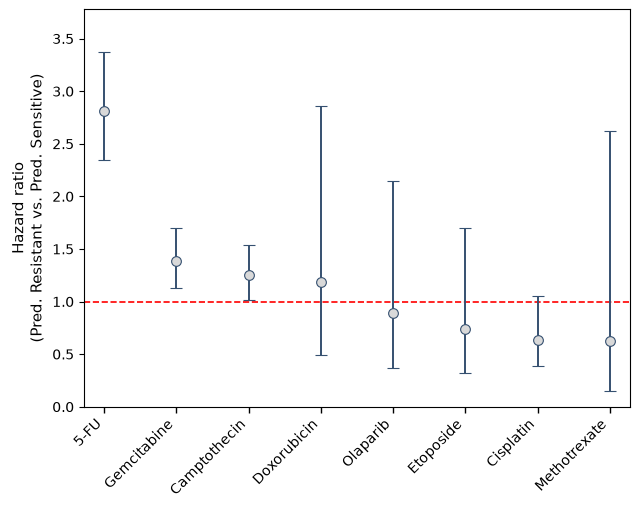

In [78]:
# ============================================================
# ENTIRE-DRUG-COHORT HAZARD-RATIO MODEL COMPARISON
# WITH OPTIONAL BASELINES
# ============================================================
#
# Compares hazard ratios across the ENTIRE cohort of patients
# treated with each drug, regardless of cancer type.
#
# For each drug:
#
#   DRPT-CoxPH:
#       split at median risk_score
#
#   DRPT-AUC:
#       split at median predicted_auc
#
#   ElasticNet:
#       split at median elasticnet_auc
#
# Sensitive:
#       score <= median
#
# Resistant:
#       score > median
#
# Cox model:
#
#       PFS ~ predicted_resistant
#
# Therefore:
#
#       HR > 1
#
# means the predicted-resistant group has greater progression
# hazard than the predicted-sensitive group.
#
#
# MAIN OPTION:
#
#       include_baselines=True
#
#           Plot:
#               DRPT-CoxPH
#               DRPT-AUC
#               ElasticNet
#
#
#       include_baselines=False
#
#           Plot:
#               DRPT-CoxPH only
#
#
# Required existing objects:
#
#       risk_df
#
# and, if include_baselines=True:
#
#       auc_df
#       elasticnet_df
#
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter


plt.rcParams["svg.fonttype"] = "none"


# ============================================================
# MODEL DEFINITIONS
# ============================================================

HR_MODEL_SPECS = [
    {
        "model": "DRPT-CoxPH",
        "score_col": "risk_score",
        "color": "#d9d9d9",
    },
    {
        "model": "DRPT-AUC",
        "score_col": "predicted_auc",
        "color": "#8ecae6",
    },
    {
        "model": "ElasticNet",
        "score_col": "elasticnet_auc",
        "color": "#f4a261",
    },
]


# ============================================================
# EXACT KM-STYLE HAZARD-RATIO FUNCTION
# ============================================================

def compute_hazard_ratio_binary_groups(
    dur,
    ev,
    sensitive_mask,
    resistant_mask,
):
    """
    Compute resistant-vs-sensitive hazard ratio exactly in the
    style of the Kaplan-Meier analysis.

    predicted_resistant:
        sensitive = 0
        resistant = 1

    HR > 1 therefore indicates greater progression hazard in
    the predicted-resistant group.
    """

    group = np.full(
        len(dur),
        np.nan,
    )

    group[sensitive_mask] = 0
    group[resistant_mask] = 1

    cox_df = pd.DataFrame(
        {
            "PFS_MONTHS": pd.to_numeric(
                dur,
                errors="coerce",
            ),
            "EVENT": pd.to_numeric(
                ev,
                errors="coerce",
            ),
            "predicted_resistant": group,
        }
    ).dropna()

    # Need both sensitive and resistant groups.
    if (
        cox_df["predicted_resistant"]
        .nunique()
        < 2
    ):
        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )

    # Need at least one observed event.
    if (
        cox_df["EVENT"].sum()
        == 0
    ):
        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )

    try:

        cph = CoxPHFitter()

        cph.fit(
            cox_df,
            duration_col="PFS_MONTHS",
            event_col="EVENT",
        )

        hr = float(
            np.exp(
                cph.params_[
                    "predicted_resistant"
                ]
            )
        )

        hr_lower = float(
            np.exp(
                cph.confidence_intervals_
                .loc[
                    "predicted_resistant"
                ]
                .iloc[0]
            )
        )

        hr_upper = float(
            np.exp(
                cph.confidence_intervals_
                .loc[
                    "predicted_resistant"
                ]
                .iloc[1]
            )
        )

        p_value = float(
            cph.summary.loc[
                "predicted_resistant",
                "p",
            ]
        )

        return (
            hr,
            hr_lower,
            hr_upper,
            p_value,
        )

    except Exception as exc:

        print(
            "Cox model failed:",
            type(exc).__name__,
            str(exc),
        )

        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )


# ============================================================
# PREPARE MODEL TABLE
# ============================================================

def prepare_drug_hr_model_table(
    df,
    score_col,
):
    """
    Validate and prepare one model's patient prediction table.
    """

    required_columns = {
        "SAMPLE_ID",
        "RSI_DRUG",
        "PFS_MONTHS",
        "EVENT",
        score_col,
    }

    missing_columns = (
        required_columns
        - set(df.columns)
    )

    if missing_columns:

        raise ValueError(
            f"Missing columns for {score_col}: "
            f"{missing_columns}"
        )

    out = df.copy()

    out["PFS_MONTHS"] = pd.to_numeric(
        out["PFS_MONTHS"],
        errors="coerce",
    )

    out["EVENT"] = pd.to_numeric(
        out["EVENT"],
        errors="coerce",
    )

    out[score_col] = pd.to_numeric(
        out[score_col],
        errors="coerce",
    )

    return out


# ============================================================
# GET AVAILABLE DRUGS
# ============================================================

def get_available_hr_drugs(
    risk_df,
    auc_df=None,
    elasticnet_df=None,
    include_baselines=True,
):
    """
    Identify drugs available for analysis.

    include_baselines=True:
        Return drugs common to risk_df, auc_df, and elasticnet_df.

    include_baselines=False:
        Return all drugs represented in risk_df.
    """

    risk_drugs = set(
        risk_df[
            "RSI_DRUG"
        ]
        .dropna()
        .astype(str)
    )

    if not include_baselines:

        return sorted(
            risk_drugs
        )

    if (
        auc_df is None
        or elasticnet_df is None
    ):
        raise ValueError(
            "auc_df and elasticnet_df are required "
            "when include_baselines=True."
        )

    auc_drugs = set(
        auc_df[
            "RSI_DRUG"
        ]
        .dropna()
        .astype(str)
    )

    elasticnet_drugs = set(
        elasticnet_df[
            "RSI_DRUG"
        ]
        .dropna()
        .astype(str)
    )

    common_drugs = (
        risk_drugs
        & auc_drugs
        & elasticnet_drugs
    )

    return sorted(
        common_drugs
    )


# ============================================================
# COMPUTE HR FOR ONE MODEL + ONE ENTIRE DRUG COHORT
# ============================================================

def compute_model_drug_hr(
    df,
    score_col,
    drug_name,
):
    """
    Compute resistant-vs-sensitive HR across the ENTIRE population
    receiving a given drug.

    There is NO cancer-type filtering.

    Threshold:
        median model prediction among all patients receiving
        the selected drug.

    Sensitive:
        score <= median

    Resistant:
        score > median
    """

    df = prepare_drug_hr_model_table(
        df=df,
        score_col=score_col,
    )

    # --------------------------------------------------------
    # Select all patients receiving this drug
    # --------------------------------------------------------

    drug_df = df[
        df["RSI_DRUG"]
        == drug_name
    ].copy()

    if drug_df.empty:

        raise ValueError(
            f"No patients found for drug: "
            f"{drug_name}"
        )

    # --------------------------------------------------------
    # Extract prediction / survival information
    # --------------------------------------------------------

    score = pd.to_numeric(
        drug_df[score_col],
        errors="coerce",
    ).to_numpy(dtype=float)

    dur = pd.to_numeric(
        drug_df["PFS_MONTHS"],
        errors="coerce",
    ).to_numpy(dtype=float)

    ev = pd.to_numeric(
        drug_df["EVENT"],
        errors="coerce",
    ).to_numpy(dtype=float)

    # --------------------------------------------------------
    # Remove invalid observations
    # --------------------------------------------------------

    valid = (
        np.isfinite(score)
        & np.isfinite(dur)
        & np.isfinite(ev)
        & (dur > 0)
    )

    score = score[
        valid
    ]

    dur = dur[
        valid
    ]

    ev = ev[
        valid
    ].astype(int)

    if len(score) == 0:

        raise ValueError(
            f"No valid patients for "
            f"{drug_name} / {score_col}"
        )

    # --------------------------------------------------------
    # Calculate median score for this ENTIRE drug cohort
    # --------------------------------------------------------

    cutoff = float(
        np.median(
            score
        )
    )

    # --------------------------------------------------------
    # Sensitive / resistant stratification
    # --------------------------------------------------------

    sensitive_mask = (
        score <= cutoff
    )

    resistant_mask = (
        score > cutoff
    )

    # --------------------------------------------------------
    # Compute HR
    # --------------------------------------------------------

    (
        hr,
        hr_lower,
        hr_upper,
        p_value,
    ) = compute_hazard_ratio_binary_groups(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive_mask,
        resistant_mask=resistant_mask,
    )

    # --------------------------------------------------------
    # Patient / event counts
    # --------------------------------------------------------

    n_total = int(
        len(score)
    )

    n_sensitive = int(
        sensitive_mask.sum()
    )

    n_resistant = int(
        resistant_mask.sum()
    )

    n_events = int(
        ev.sum()
    )

    n_sensitive_events = int(
        ev[
            sensitive_mask
        ].sum()
    )

    n_resistant_events = int(
        ev[
            resistant_mask
        ].sum()
    )

    return {
        "hazard_ratio": hr,
        "ci_lower": hr_lower,
        "ci_upper": hr_upper,
        "p_value": p_value,

        "cutoff": cutoff,

        "n_total": n_total,

        "n_sensitive": n_sensitive,
        "n_resistant": n_resistant,

        "n_events": n_events,

        "n_sensitive_events":
            n_sensitive_events,

        "n_resistant_events":
            n_resistant_events,
    }


# ============================================================
# COLLECT ALL DRUG HR RESULTS
# ============================================================

def collect_drug_hr_comparison_results(
    risk_df,
    auc_df,
    elasticnet_df,
    drug_names,
    include_baselines=True,
):
    """
    Compute resistant-vs-sensitive HR across each entire drug
    cohort.

    include_baselines=True:
        DRPT-CoxPH
        DRPT-AUC
        ElasticNet

    include_baselines=False:
        DRPT-CoxPH only
    """

    if include_baselines:

        model_specs = (
            HR_MODEL_SPECS
        )

        model_tables = {
            "DRPT-CoxPH":
                risk_df,

            "DRPT-AUC":
                auc_df,

            "ElasticNet":
                elasticnet_df,
        }

    else:

        model_specs = [
            spec
            for spec in HR_MODEL_SPECS
            if spec["model"]
            == "DRPT-CoxPH"
        ]

        model_tables = {
            "DRPT-CoxPH":
                risk_df,
        }

    rows = []

    for drug_order, drug_name in enumerate(
        drug_names
    ):

        for model_order, spec in enumerate(
            model_specs
        ):

            model_name = (
                spec["model"]
            )

            score_col = (
                spec["score_col"]
            )

            model_df = (
                model_tables[
                    model_name
                ]
            )

            try:

                result = (
                    compute_model_drug_hr(
                        df=model_df,
                        score_col=score_col,
                        drug_name=drug_name,
                    )
                )

                fit_status = (
                    "success"
                )

            except Exception as exc:

                print(
                    f"Failed: "
                    f"{drug_name} / "
                    f"{model_name}: "
                    f"{type(exc).__name__}: "
                    f"{exc}"
                )

                result = {
                    "hazard_ratio":
                        np.nan,

                    "ci_lower":
                        np.nan,

                    "ci_upper":
                        np.nan,

                    "p_value":
                        np.nan,

                    "cutoff":
                        np.nan,

                    "n_total":
                        0,

                    "n_sensitive":
                        0,

                    "n_resistant":
                        0,

                    "n_events":
                        0,

                    "n_sensitive_events":
                        0,

                    "n_resistant_events":
                        0,
                }

                fit_status = (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                )

            rows.append(
                {
                    "drug_order":
                        drug_order,

                    "model_order":
                        model_order,

                    "drug":
                        drug_name,

                    "model":
                        model_name,

                    "score_col":
                        score_col,

                    "threshold_scope":
                        "entire_drug_median",

                    "fit_status":
                        fit_status,

                    **result,
                }
            )

    return pd.DataFrame(
        rows
    )


# ============================================================
# FORMAT RESULTS
# ============================================================

def format_drug_hr_results(
    results_df,
):
    """
    Add manuscript-friendly HR / 95% CI / P-value columns.
    """

    output = (
        results_df.copy()
    )

    output["HR_95CI"] = (
        output.apply(
            lambda row: (
                f"{row['hazard_ratio']:.2f} "
                f"({row['ci_lower']:.2f}–"
                f"{row['ci_upper']:.2f})"

                if (
                    np.isfinite(
                        row["hazard_ratio"]
                    )
                    and
                    np.isfinite(
                        row["ci_lower"]
                    )
                    and
                    np.isfinite(
                        row["ci_upper"]
                    )
                )

                else "NA"
            ),
            axis=1,
        )
    )

    def format_p(p):

        if not np.isfinite(p):
            return "NA"

        if p < 0.0001:
            return "<0.0001"

        if p < 0.001:
            return "<0.001"

        return f"{p:.3f}"

    output["p_formatted"] = (
        output[
            "p_value"
        ].apply(
            format_p
        )
    )

    return output


# ============================================================
# PLOT DRUG HR COMPARISON
# ============================================================

def plot_drug_hr_comparison(
    results_df,
    include_baselines=True,
    figsize=(8.0, 5.5),
    output_svg=(
        "drpt_hazard_ratio_entire_drug_cohort.svg"
    ),
    output_png=(
        "drpt_hazard_ratio_entire_drug_cohort.png"
    ),
    y_padding_fraction=0.12,
    show_hr_labels=False,
):
    """
    Plot resistant-vs-sensitive HR and 95% CI across entire
    drug-treated cohorts.

    Drugs are ordered from highest to lowest DRPT-CoxPH HR.

    include_baselines=True:
        DRPT-CoxPH
        DRPT-AUC
        ElasticNet

    include_baselines=False:
        DRPT-CoxPH only
    """

    plot_df = (
        results_df.copy()
    )

    # --------------------------------------------------------
    # Models to display
    # --------------------------------------------------------

    if include_baselines:

        model_specs = (
            HR_MODEL_SPECS
        )

    else:

        model_specs = [
            spec
            for spec in HR_MODEL_SPECS
            if spec["model"]
            == "DRPT-CoxPH"
        ]

    model_order = [
        spec["model"]
        for spec in model_specs
    ]

    color_map = {
        spec["model"]:
        spec["color"]
        for spec in model_specs
    }

    # ========================================================
    # ORDER DRUGS FROM HIGHEST TO LOWEST DRPT-CoxPH HR
    # ========================================================

    coxph_order_df = (
        plot_df[
            plot_df["model"]
            == "DRPT-CoxPH"
        ][
            [
                "drug",
                "hazard_ratio",
                "drug_order",
            ]
        ]
        .drop_duplicates(
            subset=[
                "drug"
            ]
        )
        .sort_values(
            by=[
                "hazard_ratio",
                "drug_order",
            ],
            ascending=[
                False,
                True,
            ],
            na_position="last",
        )
    )

    drug_order = (
        coxph_order_df[
            "drug"
        ].tolist()
    )

    n_drugs = len(
        drug_order
    )

    x_centers = (
        np.arange(
            n_drugs,
            dtype=float,
        )
    )

    # --------------------------------------------------------
    # Model offsets
    # --------------------------------------------------------

    if len(model_order) == 1:

        # DRPT-only:
        # place each point directly at the center of the drug.
        offsets = np.array(
            [0.0]
        )

    else:

        offsets = np.linspace(
            -0.22,
            0.22,
            len(model_order),
        )

    # ========================================================
    # FIGURE
    # ========================================================

    fig, ax = plt.subplots(
        figsize=figsize
    )

    edge_color = (
        "#355070"
    )

    # ========================================================
    # PLOT EACH MODEL
    # ========================================================

    for model_index, model_name in enumerate(
        model_order
    ):

        model_df = (
            plot_df[
                plot_df["model"]
                == model_name
            ]
            .set_index(
                "drug"
            )
            .reindex(
                drug_order
            )
            .reset_index()
        )

        x_model = (
            x_centers
            + offsets[
                model_index
            ]
        )

        hr = (
            model_df[
                "hazard_ratio"
            ]
            .to_numpy(
                dtype=float
            )
        )

        ci_lower = (
            model_df[
                "ci_lower"
            ]
            .to_numpy(
                dtype=float
            )
        )

        ci_upper = (
            model_df[
                "ci_upper"
            ]
            .to_numpy(
                dtype=float
            )
        )

        valid = (
            np.isfinite(hr)
            & np.isfinite(ci_lower)
            & np.isfinite(ci_upper)
        )

        lower_error = (
            hr[valid]
            - ci_lower[valid]
        )

        upper_error = (
            ci_upper[valid]
            - hr[valid]
        )

        ax.errorbar(
            x_model[
                valid
            ],

            hr[
                valid
            ],

            yerr=np.vstack(
                [
                    lower_error,
                    upper_error,
                ]
            ),

            fmt="o",

            markersize=7,

            markerfacecolor=(
                color_map[
                    model_name
                ]
            ),

            markeredgecolor=(
                edge_color
            ),

            markeredgewidth=0.8,

            ecolor=(
                edge_color
            ),

            elinewidth=1.4,

            capsize=4,

            capthick=1.2,

            linestyle="none",

            label=(
                model_name
            ),

            zorder=3,
        )

        # ----------------------------------------------------
        # Optional numerical HR values above the CI
        # ----------------------------------------------------

        if show_hr_labels:

            for (
                xi,
                hr_value,
                upper_value,
            ) in zip(
                x_model,
                hr,
                ci_upper,
            ):

                if (
                    np.isfinite(
                        hr_value
                    )
                    and
                    np.isfinite(
                        upper_value
                    )
                ):

                    ax.text(
                        xi,
                        upper_value,
                        f"{hr_value:.2f}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                        clip_on=False,
                    )

    # ========================================================
    # HR = 1 NULL LINE
    # ========================================================

    ax.axhline(
        1.0,
        color="red",
        linestyle="--",
        linewidth=1.2,
        zorder=1,
    )

    # ========================================================
    # Y-AXIS LIMIT
    # ========================================================

    # Only use models currently displayed to determine y-range.
    plotted_df = (
        plot_df[
            plot_df[
                "model"
            ].isin(
                model_order
            )
        ]
    )

    all_upper = pd.to_numeric(
        plotted_df[
            "ci_upper"
        ],
        errors="coerce",
    ).to_numpy(
        dtype=float
    )

    valid_upper = (
        all_upper[
            np.isfinite(
                all_upper
            )
        ]
    )

    if len(valid_upper) > 0:

        maximum_ci = float(
            np.max(
                valid_upper
            )
        )

        y_max = (
            maximum_ci
            * (
                1.0
                + y_padding_fraction
            )
        )

    else:

        y_max = 2.0

    # Always show HR = 1.
    y_max = max(
        y_max,
        1.2,
    )

    ax.set_ylim(
        0,
        y_max,
    )

    # ========================================================
    # AXIS LABELS
    # ========================================================

    ax.set_ylabel(
        "Hazard ratio\n"
        "(Pred. Resistant vs. Pred. Sensitive)",
        fontsize=11,
    )

    ax.set_xticks(
        x_centers
    )

    ax.set_xticklabels(
        drug_order,
        rotation=45,
        ha="right",
        fontsize=10,
    )

    ax.tick_params(
        axis="x",
        length=4,
        width=1,
        direction="out",
    )

    ax.tick_params(
        axis="y",
        labelsize=10,
    )

    ax.grid(
        False
    )

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    if include_baselines:

        ax.legend(
            fontsize=10,
            frameon=False,
            loc="upper right",
        )

    # No legend needed when only DRPT-CoxPH is shown.

    ax.set_title(
        ""
    )

    ax.margins(
        x=0.04
    )

    fig.tight_layout()

    fig.subplots_adjust(
        bottom=0.25
    )

    # ========================================================
    # SAVE FIGURE
    # ========================================================

    if output_svg is not None:

        fig.savefig(
            output_svg,
            format="svg",
            bbox_inches="tight",
        )

    if output_png is not None:

        fig.savefig(
            output_png,
            dpi=600,
            bbox_inches="tight",
        )

    plt.show()


# ============================================================
# COMPLETE WRAPPER FUNCTION
# ============================================================

def run_drug_hazard_ratio_comparison(
    risk_df,
    auc_df=None,
    elasticnet_df=None,
    drug_names=None,

    # --------------------------------------------------------
    # MAIN OPTION:
    #
    # True  = DRPT-CoxPH + DRPT-AUC + ElasticNet
    # False = DRPT-CoxPH only
    # --------------------------------------------------------

    include_baselines=True,

    output_csv=(
        "drug_cohort_hazard_ratio_"
        "comparison_results.csv"
    ),

    output_svg=(
        "drug_cohort_hazard_ratio_"
        "comparison.svg"
    ),

    output_png=(
        "drug_cohort_hazard_ratio_"
        "comparison.png"
    ),

    figsize=(8.0, 5.5),

    show_hr_labels=False,
):
    """
    Run HR analysis across entire drug-treated cohorts.

    Parameters
    ----------
    include_baselines : bool

        True:
            Analyze and plot:
                DRPT-CoxPH
                DRPT-AUC
                ElasticNet

        False:
            Analyze and plot:
                DRPT-CoxPH only

            auc_df and elasticnet_df are not required.

    drug_names : list or None

        None:
            Automatically determine available drugs.

        list:
            Manually specify drugs to include.
    """

    # ========================================================
    # CHECK BASELINE INPUTS
    # ========================================================

    if include_baselines:

        if auc_df is None:

            raise ValueError(
                "auc_df is required when "
                "include_baselines=True."
            )

        if elasticnet_df is None:

            raise ValueError(
                "elasticnet_df is required when "
                "include_baselines=True."
            )

    # ========================================================
    # IDENTIFY DRUGS
    # ========================================================

    if drug_names is None:

        drug_names = (
            get_available_hr_drugs(
                risk_df=risk_df,
                auc_df=auc_df,
                elasticnet_df=elasticnet_df,
                include_baselines=include_baselines,
            )
        )

    # ========================================================
    # PRINT INCLUDED DRUGS
    # ========================================================

    print(
        "\n"
        "===================================================="
    )

    if include_baselines:

        print(
            "ENTIRE-DRUG HAZARD-RATIO MODEL COMPARISON"
        )

    else:

        print(
            "DRPT-CoxPH ENTIRE-DRUG HAZARD-RATIO ANALYSIS"
        )

    print(
        "====================================================\n"
    )

    print(
        f"Include baselines: "
        f"{include_baselines}"
    )

    print(
        f"Number of drugs: "
        f"{len(drug_names)}\n"
    )

    for i, drug_name in enumerate(
        drug_names,
        start=1,
    ):

        print(
            f"{i}. {drug_name}"
        )

    if len(drug_names) != 8:

        print(
            "\nWARNING: "
            f"Expected approximately 8 drug cohorts, "
            f"but found {len(drug_names)}."
        )

    # ========================================================
    # CALCULATE HAZARD RATIOS
    # ========================================================

    results = (
        collect_drug_hr_comparison_results(
            risk_df=risk_df,
            auc_df=auc_df,
            elasticnet_df=elasticnet_df,
            drug_names=drug_names,
            include_baselines=include_baselines,
        )
    )

    # ========================================================
    # FORMAT RESULTS
    # ========================================================

    results = (
        format_drug_hr_results(
            results
        )
    )

    # ========================================================
    # ORDER DRUGS BY DRPT-CoxPH HAZARD RATIO
    # ========================================================

    cox_order = (
        results[
            results["model"]
            == "DRPT-CoxPH"
        ][
            [
                "drug",
                "hazard_ratio",
            ]
        ]
        .drop_duplicates(
            subset=[
                "drug"
            ]
        )
        .sort_values(
            "hazard_ratio",
            ascending=False,
            na_position="last",
        )
        ["drug"]
        .tolist()
    )

    drug_rank = {
        drug: rank
        for rank, drug
        in enumerate(
            cox_order
        )
    }

    results[
        "coxph_hr_rank"
    ] = (
        results[
            "drug"
        ].map(
            drug_rank
        )
    )

    results = (
        results
        .sort_values(
            [
                "coxph_hr_rank",
                "model_order",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(
        "\n"
        "===================================================="
    )

    print(
        "HAZARD-RATIO RESULTS"
    )

    print(
        "====================================================\n"
    )

    print(
        "Each drug is stratified at the median prediction "
        "for that model."
    )

    print(
        "HR = predicted resistant vs predicted sensitive.\n"
    )

    display_columns = [
        "drug",
        "model",
        "n_total",
        "n_events",
        "n_sensitive",
        "n_resistant",
        "n_sensitive_events",
        "n_resistant_events",
        "cutoff",
        "hazard_ratio",
        "ci_lower",
        "ci_upper",
        "HR_95CI",
        "p_value",
        "p_formatted",
    ]

    print(
        results[
            display_columns
        ].to_string(
            index=False
        )
    )

    # ========================================================
    # SAVE RESULTS
    # ========================================================

    if output_csv is not None:

        results.to_csv(
            output_csv,
            index=False,
        )

    # ========================================================
    # GENERATE PLOT
    # ========================================================

    plot_drug_hr_comparison(
        results_df=results,
        include_baselines=include_baselines,
        figsize=figsize,
        output_svg=output_svg,
        output_png=output_png,
        show_hr_labels=show_hr_labels,
    )

    return results


# ============================================================
# RUN ANALYSIS
# ============================================================
#
# OPTION 1:
#
#     include_baselines=False
#
# Shows only DRPT-CoxPH.
#
#
# OPTION 2:
#
#     include_baselines=True
#
# Shows:
#
#     DRPT-CoxPH
#     DRPT-AUC
#     ElasticNet
#
# ============================================================


drug_hr_comparison_results = (
    run_drug_hazard_ratio_comparison(

        risk_df=risk_df,

        auc_df=auc_df,

        elasticnet_df=elasticnet_df,

        # ----------------------------------------------------
        # Automatically use all available drug cohorts.
        # ----------------------------------------------------

        drug_names=None,

        # ----------------------------------------------------
        # CHANGE THIS OPTION
        #
        # False = DRPT-CoxPH only
        # True  = include DRPT-AUC and ElasticNet
        # ----------------------------------------------------

        include_baselines=False,

        # ----------------------------------------------------
        # Outputs
        # ----------------------------------------------------

        output_csv=(
            "drug_cohort_hazard_ratio_"
            "drpt_coxph_only_results.csv"
        ),

        output_svg=(
            "drpt_coxph_hazard_ratio_"
            "entire_drug_cohort.svg"
        ),

        output_png=(
            "drpt_coxph_hazard_ratio_"
            "entire_drug_cohort.png"
        ),

        figsize=(6.5, 5.5),

        # Set True if you want the HR number printed
        # above each confidence interval.
        show_hr_labels=False,
    )
)

## Create Oncoprint

Explore different oncoprints for drug + cancer type combinations. Select genes that are

1. Top 20 most important for the drug
2. Genes in one of the most important system
3. Genes with strongest shift in alterations from pred. res to pred. sen

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import csv
import math
from pathlib import Path

### Load in system and gene importance

In [5]:
with open("mappings/system_to_genes.pkl", "rb") as handle:
    system_to_genes = pickle.load(handle)

importance_df_systems = pd.read_csv("system_semi_partial_importance_g2d.csv")
importance_df_genes = pd.read_csv("gene_semi_partial_importance_g2d.csv")

### Re-acquire list of important genes and systems

In [6]:
import numpy as np
import pandas as pd

from statsmodels.stats.multitest import multipletests
from typing import Dict, List, Tuple, Any, Iterable, Optional


def harmonic_mean_pvalue(pvals: np.ndarray) -> float:
    """
    Harmonic mean p-value:
        p_HMP = D / sum_i(1 / p_i)

    Uses a conservative lower clipping bound to avoid floating-point overflow
    when p-values are extremely small.
    """
    pvals = np.asarray(pvals, dtype=float)
    pvals = pvals[np.isfinite(pvals)]

    if pvals.size == 0:
        return np.nan

    pvals = np.clip(pvals, 1e-300, 1.0)

    D = float(pvals.size)
    denom = np.sum(1.0 / pvals)

    if not np.isfinite(denom) or denom <= 0:
        return 0.0

    return float(D / denom)


def get_drpt_important_systems_and_genes_by_drug(
    importance_df_systems: pd.DataFrame,
    importance_df_genes: pd.DataFrame,
    system_to_genes: Dict[str, Iterable[str]],

    # Shared columns
    p_col: str = "p_pearson",
    per_drug_bonf_col: str = "p_bonferroni_pearson",
    drug_col: str = "drug",

    # System columns
    system_col: str = "system",

    # Gene columns
    gene_col: str = "gene",

    # Statistical settings
    D_expected: int = 12,
    alpha: float = 1e-4,
    require_all_drugs: bool = True,

    # Hierarchy filters
    max_system_genes: int = 100,
    restrict_genes_to_important_systems: bool = True,
    filter_systems_to_contain_important_genes: bool = True,

    # Output settings
    out_genes_csv: Optional[str] = "drpt_rsi_important_genes.csv",
    verbose: bool = True,
) -> Tuple[Dict[str, List[Dict[str, Any]]], Dict[str, List[Dict[str, Any]]], Dict[str, Any]]:
    """
    Unified DRPT important system/gene selection.

    Workflow
    --------
    1. Important systems:
       - Compute HMP across drugs using raw system p-values.
       - Bonferroni-correct HMP across all systems.
       - Keep systems with:
            p_bonf_hmp < alpha
            system size <= max_system_genes
            at least one drug with per-drug Bonferroni p < alpha

    2. Important genes:
       - Compute HMP across drugs using raw gene p-values.
       - Bonferroni-correct HMP across all genes.
       - Keep genes with:
            p_bonf_hmp < alpha
            at least one drug with per-drug Bonferroni p < alpha
            membership in at least one small system
            optionally, membership in at least one important system

    3. Optional final system filter:
       - Keep only important systems that contain at least one important gene.

    Returns
    -------
    important_systems_by_drug : dict
        {
            drug: [
                {
                    "system": system_name,
                    "p_bonferroni_drug": per-drug Bonferroni-corrected p-value,
                    "p_bonf_hmp": Bonferroni-corrected HMP p-value across drugs,
                    "system_n_genes": number of genes in system,
                    "important_gene_hits": important genes contained in this system
                },
                ...
            ],
            ...
        }

    important_genes_by_drug : dict
        {
            drug: [
                {
                    "gene": gene_name,
                    "p_bonferroni_drug": per-drug Bonferroni-corrected p-value,
                    "p_bonf_hmp": Bonferroni-corrected HMP p-value across drugs,
                    "important_systems_matched": important systems containing this gene
                },
                ...
            ],
            ...
        }

    meta : dict
        Extra full tables and mappings useful for debugging/downstream analysis.
    """

    # ------------------------------------------------------------------
    # Validate inputs
    # ------------------------------------------------------------------
    needed_system_cols = {system_col, drug_col, p_col, per_drug_bonf_col}
    missing_system_cols = needed_system_cols - set(importance_df_systems.columns)

    if missing_system_cols:
        raise KeyError(f"importance_df_systems missing required columns: {missing_system_cols}")

    needed_gene_cols = {gene_col, drug_col, p_col, per_drug_bonf_col}
    missing_gene_cols = needed_gene_cols - set(importance_df_genes.columns)

    if missing_gene_cols:
        raise KeyError(f"importance_df_genes missing required columns: {missing_gene_cols}")

    # ------------------------------------------------------------------
    # Build small-system maps
    # ------------------------------------------------------------------
    small_system_to_genes: Dict[str, set] = {}

    for sys_name, genes in (system_to_genes or {}).items():
        if genes is None:
            continue

        try:
            genes_list = list(genes)
        except Exception:
            continue

        if len(genes_list) <= int(max_system_genes):
            small_system_to_genes[str(sys_name)] = set(map(str, genes_list))

    gene_to_small_systems: Dict[str, List[str]] = {}

    for sys_name, gene_set in small_system_to_genes.items():
        for g in gene_set:
            gene_to_small_systems.setdefault(str(g), []).append(str(sys_name))

    gene_to_small_systems = {
        g: sorted(set(systems))
        for g, systems in gene_to_small_systems.items()
    }

    # ==================================================================
    # PART 1: IMPORTANT SYSTEMS
    # ==================================================================

    # ------------------------------------------------------------------
    # Prep system data for HMP
    # ------------------------------------------------------------------
    sys_hmp_df = importance_df_systems[[system_col, drug_col, p_col]].copy()
    sys_hmp_df[system_col] = sys_hmp_df[system_col].astype(str)
    sys_hmp_df[drug_col] = sys_hmp_df[drug_col].astype(str)
    sys_hmp_df[p_col] = pd.to_numeric(sys_hmp_df[p_col], errors="coerce")

    # De-duplicate system-drug pairs by keeping minimum raw p-value
    sys_hmp_df = (
        sys_hmp_df.dropna(subset=[p_col])
        .groupby([system_col, drug_col], as_index=False)[p_col]
        .min()
    )

    # ------------------------------------------------------------------
    # Compute HMP per system
    # ------------------------------------------------------------------
    system_rows = []

    for sys_name, g in sys_hmp_df.groupby(system_col, sort=False):
        pvals = g[p_col].values.astype(float)
        D_used = int(np.isfinite(pvals).sum())

        if require_all_drugs and D_used != int(D_expected):
            continue

        p_hmp = harmonic_mean_pvalue(pvals)

        system_rows.append({
            "system": str(sys_name),
            "D_used": D_used,
            "p_hmp": p_hmp,
        })

    all_systems_table = pd.DataFrame(system_rows)

    if all_systems_table.empty:
        raise ValueError(
            "No systems left after HMP aggregation. "
            "If require_all_drugs=True, check each system has p-values for all drugs."
        )

    # ------------------------------------------------------------------
    # Bonferroni correction across all systems
    # ------------------------------------------------------------------
    all_systems_table["p_bonf_hmp"] = multipletests(
        all_systems_table["p_hmp"].values.astype(float),
        alpha=float(alpha),
        method="bonferroni"
    )[1]

    all_systems_table["is_sig_hmp_bonf"] = all_systems_table["p_bonf_hmp"] < float(alpha)

    # ------------------------------------------------------------------
    # Add system size
    # ------------------------------------------------------------------
    def _n_genes_for_system(sys_name: str) -> float:
        genes = system_to_genes.get(sys_name, None)

        if genes is None:
            return np.nan

        try:
            return int(len(list(genes)))
        except Exception:
            return np.nan

    all_systems_table["system_n_genes"] = all_systems_table["system"].map(_n_genes_for_system)
    all_systems_table["passes_size"] = all_systems_table["system_n_genes"].le(int(max_system_genes))

    # ------------------------------------------------------------------
    # Per-drug system Bonferroni table
    # ------------------------------------------------------------------
    sys_drug_df = importance_df_systems[[drug_col, system_col, per_drug_bonf_col]].copy()
    sys_drug_df[drug_col] = sys_drug_df[drug_col].astype(str)
    sys_drug_df[system_col] = sys_drug_df[system_col].astype(str)
    sys_drug_df[per_drug_bonf_col] = pd.to_numeric(sys_drug_df[per_drug_bonf_col], errors="coerce")

    # De-duplicate drug-system pairs by keeping minimum per-drug Bonferroni p-value
    sys_drug_df = (
        sys_drug_df.dropna(subset=[per_drug_bonf_col])
        .groupby([drug_col, system_col], as_index=False)[per_drug_bonf_col]
        .min()
    )

    sys_drug_df["is_drug_sig"] = sys_drug_df[per_drug_bonf_col] < float(alpha)

    system_to_sig_drugs = (
        sys_drug_df[sys_drug_df["is_drug_sig"]]
        .groupby(system_col)[drug_col]
        .apply(lambda s: sorted(s.dropna().astype(str).unique().tolist()))
        .to_dict()
    )

    all_systems_table["sig_drugs"] = all_systems_table["system"].map(
        lambda s: system_to_sig_drugs.get(str(s), [])
    )

    all_systems_table["n_sig_drugs"] = all_systems_table["sig_drugs"].map(len)
    all_systems_table["has_any_sig_drug"] = all_systems_table["n_sig_drugs"] > 0

    all_systems_table["is_important_initial"] = (
        all_systems_table["is_sig_hmp_bonf"]
        & all_systems_table["passes_size"]
        & all_systems_table["has_any_sig_drug"]
    )

    important_systems_initial = (
        all_systems_table.loc[all_systems_table["is_important_initial"], "system"]
        .astype(str)
        .tolist()
    )

    important_systems_initial_set = set(important_systems_initial)

    # ==================================================================
    # PART 2: IMPORTANT GENES
    # ==================================================================

    # ------------------------------------------------------------------
    # Optional gene-to-important-system map
    # ------------------------------------------------------------------
    gene_to_important_systems_matched: Dict[str, List[str]] = {}

    if restrict_genes_to_important_systems:
        for gene, systems in gene_to_small_systems.items():
            matched = sorted([
                s for s in systems
                if s in important_systems_initial_set
            ])

            if matched:
                gene_to_important_systems_matched[gene] = matched

    # ------------------------------------------------------------------
    # Prep gene data for HMP
    # ------------------------------------------------------------------
    gene_hmp_df = importance_df_genes[[gene_col, drug_col, p_col, per_drug_bonf_col]].copy()
    gene_hmp_df[gene_col] = gene_hmp_df[gene_col].astype(str)
    gene_hmp_df[drug_col] = gene_hmp_df[drug_col].astype(str)
    gene_hmp_df[p_col] = pd.to_numeric(gene_hmp_df[p_col], errors="coerce")
    gene_hmp_df[per_drug_bonf_col] = pd.to_numeric(gene_hmp_df[per_drug_bonf_col], errors="coerce")

    # De-duplicate gene-drug pairs by keeping min raw p and min per-drug Bonferroni p
    gene_hmp_df = (
        gene_hmp_df.dropna(subset=[p_col])
        .groupby([gene_col, drug_col], as_index=False)
        .agg(
            raw_p=(p_col, "min"),
            p_bonferroni_drug=(per_drug_bonf_col, "min"),
        )
    )

    # ------------------------------------------------------------------
    # Compute HMP per gene
    # ------------------------------------------------------------------
    gene_rows = []

    for gene, g in gene_hmp_df.groupby(gene_col, sort=False):
        pvals = g["raw_p"].values.astype(float)
        D_used = int(np.isfinite(pvals).sum())

        if require_all_drugs and D_used != int(D_expected):
            continue

        p_hmp = harmonic_mean_pvalue(pvals)

        gene_rows.append({
            "gene": str(gene),
            "D_used": D_used,
            "p_hmp": p_hmp,
        })

    all_genes_table = pd.DataFrame(gene_rows)

    if all_genes_table.empty:
        raise ValueError(
            "No genes left after HMP aggregation. "
            "If require_all_drugs=True, check each gene has p-values for all drugs."
        )

    # ------------------------------------------------------------------
    # Bonferroni correction across all genes
    # ------------------------------------------------------------------
    all_genes_table["p_bonf_hmp"] = multipletests(
        all_genes_table["p_hmp"].values.astype(float),
        alpha=float(alpha),
        method="bonferroni"
    )[1]

    all_genes_table["is_sig_hmp_bonf"] = all_genes_table["p_bonf_hmp"] < float(alpha)

    # ------------------------------------------------------------------
    # Per-drug gene significance
    # ------------------------------------------------------------------
    gene_hmp_df["is_drug_sig"] = gene_hmp_df["p_bonferroni_drug"] < float(alpha)

    sig_hmp_genes = set(
        all_genes_table.loc[all_genes_table["is_sig_hmp_bonf"], "gene"]
        .astype(str)
        .tolist()
    )

    gene_hits_df = gene_hmp_df[gene_hmp_df[gene_col].isin(sig_hmp_genes)].copy()

    gene_to_sig_drugs = (
        gene_hits_df[gene_hits_df["is_drug_sig"]]
        .groupby(gene_col)[drug_col]
        .apply(lambda s: sorted(s.dropna().astype(str).unique().tolist()))
        .to_dict()
    )

    # ------------------------------------------------------------------
    # Final important gene set
    # ------------------------------------------------------------------
    genes_with_any_drug_hit = set(gene_to_sig_drugs.keys())
    genes_with_small_system = set(gene_to_small_systems.keys())

    important_genes_set = genes_with_any_drug_hit.intersection(genes_with_small_system)

    if restrict_genes_to_important_systems:
        genes_with_important_system_match = set(gene_to_important_systems_matched.keys())
        important_genes_set = important_genes_set.intersection(genes_with_important_system_match)

    important_genes = sorted(important_genes_set)

    # Add final-gene annotations to full gene table
    all_genes_table["small_systems"] = all_genes_table["gene"].map(
        lambda g: gene_to_small_systems.get(str(g), [])
    )

    all_genes_table["num_small_systems"] = all_genes_table["small_systems"].map(len)

    all_genes_table["important_systems_matched"] = all_genes_table["gene"].map(
        lambda g: gene_to_important_systems_matched.get(str(g), [])
    )

    all_genes_table["num_important_systems_matched"] = all_genes_table["important_systems_matched"].map(len)

    all_genes_table["sig_drugs"] = all_genes_table["gene"].map(
        lambda g: gene_to_sig_drugs.get(str(g), [])
    )

    all_genes_table["n_sig_drugs"] = all_genes_table["sig_drugs"].map(len)

    all_genes_table["is_important"] = all_genes_table["gene"].isin(important_genes)

    important_genes_table = (
        all_genes_table[all_genes_table["is_important"]]
        .sort_values(["n_sig_drugs", "p_bonf_hmp"], ascending=[False, True])
        .reset_index(drop=True)
    )

    # Optional CSV output
    if out_genes_csv is not None:
        save_gene_table = important_genes_table.copy()

        for c in ["small_systems", "important_systems_matched", "sig_drugs"]:
            if c in save_gene_table.columns:
                save_gene_table[c] = save_gene_table[c].map(
                    lambda L: ";".join(L) if isinstance(L, list) else ""
                )

        save_gene_table.to_csv(out_genes_csv, index=False)

    # ==================================================================
    # PART 3: FILTER SYSTEMS BY IMPORTANT GENES
    # ==================================================================

    important_gene_set = set(important_genes)

    important_gene_hits_by_system: Dict[str, List[str]] = {}

    for sys_name in important_systems_initial:
        genes = system_to_genes.get(sys_name, None)

        if genes is None:
            continue

        try:
            genes_list = list(genes)
        except Exception:
            continue

        hits = sorted({
            str(g)
            for g in genes_list
            if str(g) in important_gene_set
        })

        if hits:
            important_gene_hits_by_system[str(sys_name)] = hits

    if filter_systems_to_contain_important_genes:
        final_important_systems = [
            s for s in important_systems_initial
            if s in important_gene_hits_by_system
        ]
    else:
        final_important_systems = important_systems_initial

        for sys_name in final_important_systems:
            important_gene_hits_by_system.setdefault(str(sys_name), [])

    final_important_systems_set = set(final_important_systems)

    all_systems_table["important_gene_hits"] = all_systems_table["system"].map(
        lambda s: important_gene_hits_by_system.get(str(s), [])
    )

    all_systems_table["num_important_gene_hits"] = all_systems_table["important_gene_hits"].map(len)

    all_systems_table["is_important_final"] = all_systems_table["system"].isin(final_important_systems_set)

    important_systems_table = (
        all_systems_table[all_systems_table["is_important_final"]]
        .sort_values(["n_sig_drugs", "p_bonf_hmp"], ascending=[False, True])
        .reset_index(drop=True)
    )

    # ==================================================================
    # PART 4: BUILD OUTPUT DICTIONARIES
    # ==================================================================

    # System-level HMP p-values and sizes
    system_to_p_bonf_hmp = dict(
        zip(all_systems_table["system"].astype(str), all_systems_table["p_bonf_hmp"].astype(float))
    )

    system_to_n_genes = dict(
        zip(all_systems_table["system"].astype(str), all_systems_table["system_n_genes"])
    )

    # Gene-level HMP p-values
    gene_to_p_bonf_hmp = dict(
        zip(all_genes_table["gene"].astype(str), all_genes_table["p_bonf_hmp"].astype(float))
    )

    # ------------------------------------------------------------------
    # Important systems by drug with per-drug Bonferroni p-value
    # ------------------------------------------------------------------
    important_system_drug_hits = sys_drug_df[
        (sys_drug_df["is_drug_sig"])
        & (sys_drug_df[system_col].isin(final_important_systems_set))
    ].copy()

    important_system_drug_hits = important_system_drug_hits.sort_values(
        [drug_col, per_drug_bonf_col, system_col],
        ascending=[True, True, True]
    )

    important_systems_by_drug: Dict[str, List[Dict[str, Any]]] = {}

    for drug, g in important_system_drug_hits.groupby(drug_col, sort=True):
        entries = []

        for _, row in g.iterrows():
            sys_name = str(row[system_col])
            system_n_genes = system_to_n_genes.get(sys_name, np.nan)

            entries.append({
                "system": sys_name,
                "p_bonferroni_drug": float(row[per_drug_bonf_col]),
                "p_bonf_hmp": float(system_to_p_bonf_hmp.get(sys_name, np.nan)),
                "system_n_genes": int(system_n_genes) if pd.notna(system_n_genes) else np.nan,
                "important_gene_hits": important_gene_hits_by_system.get(sys_name, []),
            })

        important_systems_by_drug[str(drug)] = entries

    # ------------------------------------------------------------------
    # Important genes by drug with per-drug Bonferroni p-value
    # ------------------------------------------------------------------
    important_gene_drug_hits = gene_hmp_df[
        (gene_hmp_df["is_drug_sig"])
        & (gene_hmp_df[gene_col].isin(important_genes))
    ].copy()

    important_gene_drug_hits = important_gene_drug_hits.sort_values(
        [drug_col, "p_bonferroni_drug", gene_col],
        ascending=[True, True, True]
    )

    important_genes_by_drug: Dict[str, List[Dict[str, Any]]] = {}

    for drug, g in important_gene_drug_hits.groupby(drug_col, sort=True):
        entries = []

        for _, row in g.iterrows():
            gene = str(row[gene_col])

            entries.append({
                "gene": gene,
                "p_bonferroni_drug": float(row["p_bonferroni_drug"]),
                "p_bonf_hmp": float(gene_to_p_bonf_hmp.get(gene, np.nan)),
                "important_systems_matched": gene_to_important_systems_matched.get(gene, []),
            })

        important_genes_by_drug[str(drug)] = entries

    # ==================================================================
    # Metadata
    # ==================================================================
    meta = {
        "important_systems_initial": important_systems_initial,
        "important_systems_final": final_important_systems,
        "important_genes": important_genes,

        "important_systems_table": important_systems_table,
        "important_genes_table": important_genes_table,

        "all_systems_table": all_systems_table,
        "all_genes_table": all_genes_table,

        "important_gene_hits_by_system": important_gene_hits_by_system,
        "gene_to_small_systems": gene_to_small_systems,
        "gene_to_important_systems_matched": gene_to_important_systems_matched,

        "alpha": alpha,
        "D_expected": D_expected,
        "require_all_drugs": require_all_drugs,
        "max_system_genes": max_system_genes,
        "out_genes_csv": out_genes_csv,
    }

    if verbose:
        print("DRPT important system/gene selection complete.")
        print()
        print(f"Systems tested by HMP: {len(all_systems_table)}")
        print(f"Initial important systems: {len(important_systems_initial)}")
        print(f"Final important systems after gene-hit filter: {len(final_important_systems)}")
        print()
        print(f"Genes tested by HMP: {len(all_genes_table)}")
        print(f"Final important genes: {len(important_genes)}")
        print()
        print(f"Drugs with important systems: {len(important_systems_by_drug)}")
        print(f"Drugs with important genes: {len(important_genes_by_drug)}")

        if out_genes_csv is not None:
            print(f"\nSaved important genes table to: {out_genes_csv}")

    return important_systems_by_drug, important_genes_by_drug, meta


# ---------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------

important_systems_by_drug, important_genes_by_drug, meta = get_drpt_important_systems_and_genes_by_drug(
    importance_df_systems=importance_df_systems,
    importance_df_genes=importance_df_genes,
    system_to_genes=system_to_genes,

    p_col="p_pearson",
    per_drug_bonf_col="p_bonferroni_pearson",
    drug_col="drug",
    system_col="system",
    gene_col="gene",

    D_expected=12,
    alpha=1e-4,
    require_all_drugs=True,
    max_system_genes=100,

    restrict_genes_to_important_systems=True,
    filter_systems_to_contain_important_genes=True,

    out_genes_csv="drpt_rsi_important_genes.csv",
    verbose=True,
)

# Final lists, if needed
important_systems = meta["important_systems_final"]
important_genes = meta["important_genes"]

# Full tables, if needed
important_systems_table = meta["important_systems_table"]
important_genes_table = meta["important_genes_table"]

# The two requested dictionaries
#important_systems_by_drug
#important_genes_by_drug

DRPT important system/gene selection complete.

Systems tested by HMP: 131
Initial important systems: 51
Final important systems after gene-hit filter: 49

Genes tested by HMP: 718
Final important genes: 129

Drugs with important systems: 11
Drugs with important genes: 12

Saved important genes table to: drpt_rsi_important_genes.csv


## Explore Creation of Oncoprints

#### Load patient results

In [7]:
survival_table = pd.read_csv("msk_embedding_transfer_mlp_cox_ph_risk_1_risk_scores.tsv", sep = "\t")
survival_table.head()

,ROW_ID,PATIENT_ID,SAMPLE_ID,RSI_DRUG,PFS_MONTHS,PFS_STATUS,EVENT,fold,risk_score
0,0,P-0000426,P-0000426-T01-IM3,Cisplatin,106.865966,1:PROGRESSION,1,1,-0.952668
1,1,P-0000562,P-0000562-T01-IM3,5-FU,15.571616,1:PROGRESSION,1,5,-0.286347
2,2,P-0000562,P-0000562-T01-IM3,Camptothecin,15.571616,1:PROGRESSION,1,5,0.663390
3,3,P-0000674,P-0000674-T01-IM3,5-FU,17.936925,1:PROGRESSION,1,3,-0.001091
4,4,P-0000714,P-0000714-T01-IM3,5-FU,1.511170,1:PROGRESSION,1,3,0.016547


In [8]:
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

try:
    from scipy.stats import fisher_exact
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

plt.rcParams["svg.fonttype"] = "none"


# ------------------------------------------------------------
# IO helpers
# ------------------------------------------------------------
def load_index_map(path):
    mapping = {}
    with open(path, newline="") as handle:
        reader = csv.reader(handle, delimiter="\t")
        for row in reader:
            if not row:
                continue
            if len(row) >= 2 and row[0].strip().lower() == "index" and row[1].strip().lower() in {"sample", "gene"}:
                continue
            mapping[str(row[1])] = int(row[0])
    return mapping


def load_binary_matrix(path, n_rows=None):
    rows = []
    with open(path, newline="") as handle:
        reader = csv.reader(handle)
        for row in reader:
            if not row:
                continue
            if len(row) == 1:
                values = row[0].strip().strip('"').split(",")
            else:
                values = [v.strip().strip('"') for v in row]
            values = [v for v in values if v != ""]
            rows.append([int(v) for v in values])

    arr = np.asarray(rows, dtype=np.int8)

    if n_rows is not None and arr.shape[0] != n_rows:
        raise ValueError(f"{path}: expected {n_rows} rows, got {arr.shape[0]}")

    return arr


def encode_event(series):
    return series.astype(str).str.split(":").str[0].astype(int)


# ------------------------------------------------------------
# Cohort loading
# ------------------------------------------------------------
def load_msk_cohort_for_oncoprint(
    risk_table,
    patient_table,
    drug_name,
    cancer_type,
):
    risk_df = pd.read_csv(risk_table, sep="\t")
    patient_df = pd.read_csv(patient_table, sep="\t")

    required_risk = {"SAMPLE_ID", "RSI_DRUG", "risk_score"}
    missing_risk = required_risk - set(risk_df.columns)
    if missing_risk:
        raise ValueError(f"Missing required columns in risk table: {missing_risk}")

    required_patient = {"SAMPLE_ID", "CANCER_TYPE", "PFS_MONTHS", "PFS_STATUS"}
    missing_patient = required_patient - set(patient_df.columns)
    if missing_patient:
        raise ValueError(f"Missing required columns in patient table: {missing_patient}")

    patient_cols = [
        "PATIENT_ID", "SAMPLE_ID", "CANCER_TYPE", "PFS_MONTHS", "PFS_STATUS", "RSI_DRUG"
    ]
    patient_cols = [c for c in patient_cols if c in patient_df.columns]

    merged = risk_df.merge(
        patient_df[patient_cols].drop_duplicates(),
        on=["SAMPLE_ID", "RSI_DRUG"],
        how="left",
        suffixes=("", "_patient"),
    )

    drug_df = merged[merged["RSI_DRUG"] == drug_name].copy()
    if drug_df.empty:
        raise ValueError(f"No rows found in risk table for drug: {drug_name}")

    drug_df["risk_score"] = pd.to_numeric(drug_df["risk_score"], errors="coerce")
    drug_df = drug_df.dropna(subset=["risk_score"])
    if drug_df.empty:
        raise ValueError(f"No non-missing risk scores found for drug: {drug_name}")

    risk_cutoff = float(np.median(drug_df["risk_score"].values))

    cancer_df = drug_df[drug_df["CANCER_TYPE"] == cancer_type].copy()
    if cancer_df.empty:
        raise ValueError(f"No rows found for drug={drug_name} and cancer_type={cancer_type}")

    cancer_df["PFS_MONTHS"] = pd.to_numeric(cancer_df["PFS_MONTHS"], errors="coerce")
    cancer_df["EVENT"] = encode_event(cancer_df["PFS_STATUS"])
    cancer_df["predicted_group"] = np.where(
        cancer_df["risk_score"] <= risk_cutoff,
        "sensitive",
        "resistant",
    )

    cancer_df = cancer_df.dropna(subset=["PFS_MONTHS"]).copy()
    if cancer_df.empty:
        raise ValueError("All rows were dropped after requiring PFS_MONTHS.")

    return cancer_df, risk_cutoff


def load_msk_alteration_matrices(
    mutation_file,
    amplification_file,
    deletion_file,
    patient2ind_file,
    gene2ind_file,
):
    sample_to_idx = load_index_map(patient2ind_file)
    gene_to_idx = load_index_map(gene2ind_file)

    n_rows = len(sample_to_idx)
    mut = load_binary_matrix(mutation_file, n_rows=n_rows)
    amp = load_binary_matrix(amplification_file, n_rows=n_rows)
    dele = load_binary_matrix(deletion_file, n_rows=n_rows)

    n_genes = len(gene_to_idx)
    if mut.shape[1] != n_genes or amp.shape[1] != n_genes or dele.shape[1] != n_genes:
        raise ValueError(
            f"Gene dimension mismatch: expected {n_genes}, got "
            f"mut={mut.shape[1]}, amp={amp.shape[1]}, del={dele.shape[1]}"
        )

    return sample_to_idx, gene_to_idx, mut, amp, dele


def build_gene_level_table(
    cohort_df,
    sample_to_idx,
    gene_to_idx,
    mut,
    amp,
    dele,
):
    valid_rows = cohort_df["SAMPLE_ID"].isin(sample_to_idx.keys()).copy()
    cohort_df = cohort_df.loc[valid_rows].copy()

    if cohort_df.empty:
        raise ValueError("None of the selected SAMPLE_ID values matched patient2ind_msk.txt")

    sample_indices = np.array([sample_to_idx[s] for s in cohort_df["SAMPLE_ID"]], dtype=int)

    mut_sub = mut[sample_indices, :]
    amp_sub = amp[sample_indices, :]
    del_sub = dele[sample_indices, :]

    cohort_df = cohort_df.reset_index(drop=True).copy()
    cohort_df["matrix_row"] = np.arange(len(cohort_df), dtype=int)

    any_global = (mut.sum(axis=0) + amp.sum(axis=0) + dele.sum(axis=0)) > 0

    idx_to_gene = {idx: gene for gene, idx in gene_to_idx.items()}
    genes_in_order = [idx_to_gene[i] for i in range(len(idx_to_gene))]

    stats = []
    resistant_mask = cohort_df["predicted_group"].eq("resistant").to_numpy()
    sensitive_mask = cohort_df["predicted_group"].eq("sensitive").to_numpy()

    any_sub = (mut_sub + amp_sub + del_sub) > 0

    n_res = int(resistant_mask.sum())
    n_sens = int(sensitive_mask.sum())

    for gene_idx, gene in enumerate(genes_in_order):
        if not any_global[gene_idx]:
            continue

        alt_vec = any_sub[:, gene_idx].astype(int)

        if n_res > 0:
            res_prev = float(alt_vec[resistant_mask].mean())
            res_alt = int(alt_vec[resistant_mask].sum())
        else:
            res_prev = np.nan
            res_alt = 0

        if n_sens > 0:
            sens_prev = float(alt_vec[sensitive_mask].mean())
            sens_alt = int(alt_vec[sensitive_mask].sum())
        else:
            sens_prev = np.nan
            sens_alt = 0

        abs_diff = abs(res_prev - sens_prev) if np.isfinite(res_prev) and np.isfinite(sens_prev) else np.nan

        p_value = np.nan
        odds_ratio = np.nan
        if HAVE_SCIPY and n_res > 0 and n_sens > 0:
            table = np.array([
                [res_alt, n_res - res_alt],
                [sens_alt, n_sens - sens_alt],
            ], dtype=int)
            try:
                odds_ratio, p_value = fisher_exact(table, alternative="two-sided")
            except Exception:
                pass

        stats.append({
            "gene": gene,
            "gene_idx": gene_idx,
            "resistant_prev": res_prev,
            "sensitive_prev": sens_prev,
            "abs_diff": abs_diff,
            "fisher_p": p_value,
            "odds_ratio": odds_ratio,
            "global_any_alt": True,
        })

    gene_stats_df = pd.DataFrame(stats)
    if gene_stats_df.empty:
        raise ValueError("No globally altered genes were available after filtering.")

    return cohort_df, mut_sub, amp_sub, del_sub, gene_stats_df


# ------------------------------------------------------------
# Gene selection
# ------------------------------------------------------------
def select_oncoprint_genes(
    gene_stats_df,
    gene_list=None,
    top_n=25,
):
    if top_n <= 0:
        raise ValueError("top_n must be positive.")
    top_n = min(int(top_n), 25)

    if gene_list is not None:
        requested = [str(g) for g in gene_list]
        keep = gene_stats_df[gene_stats_df["gene"].isin(requested)].copy()

        if keep.empty:
            raise ValueError("None of the requested genes remained after MSK filtering.")

        if len(keep) > top_n:
            keep = keep.iloc[:top_n].copy()
    else:
        ranked = gene_stats_df.copy()

        if HAVE_SCIPY and ranked["fisher_p"].notna().any():
            ranked = ranked.sort_values(
                ["fisher_p", "abs_diff", "resistant_prev"],
                ascending=[True, False, False],
            )
        else:
            ranked = ranked.sort_values(
                ["abs_diff", "resistant_prev"],
                ascending=[False, False],
            )

        keep = ranked.head(top_n).copy()

    keep = keep.sort_values(
        ["resistant_prev", "sensitive_prev", "abs_diff", "gene"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

    return keep


# ------------------------------------------------------------
# Ordering helpers
# ------------------------------------------------------------
def order_patients_for_oncoprint(group_df, selected_gene_indices, mut_sub, amp_sub, del_sub):
    row_idx = group_df["matrix_row"].to_numpy(dtype=int)

    mut_g = mut_sub[row_idx][:, selected_gene_indices]
    amp_g = amp_sub[row_idx][:, selected_gene_indices]
    del_g = del_sub[row_idx][:, selected_gene_indices]

    any_alt = ((mut_g + amp_g + del_g) > 0).astype(int)
    burden = any_alt.sum(axis=1)

    pattern_score = []
    weights = 2 ** np.arange(any_alt.shape[1] - 1, -1, -1) if any_alt.shape[1] > 0 else np.array([1])
    for row in any_alt:
        if len(row) == 0:
            pattern_score.append(0)
        else:
            pattern_score.append(int(np.dot(row, weights)))

    ordered = group_df.copy()
    ordered["_burden"] = burden
    ordered["_pattern"] = pattern_score
    ordered = ordered.sort_values(
        ["_burden", "_pattern", "PFS_MONTHS"],
        ascending=[False, False, True],
    ).drop(columns=["_burden", "_pattern"])

    return ordered


# ------------------------------------------------------------
# Alteration summaries for side bars
# ------------------------------------------------------------
def compute_group_alteration_breakdown(group_df, selected_gene_indices, mut_sub, amp_sub, del_sub):
    row_idx = group_df["matrix_row"].to_numpy(dtype=int)
    n = len(row_idx)

    rows = []
    for gene_idx in selected_gene_indices:
        if n == 0:
            rows.append({"amp": 0.0, "del": 0.0, "mut": 0.0, "any": 0.0})
            continue

        amp_prev = float((amp_sub[row_idx, gene_idx] > 0).mean())
        del_prev = float((del_sub[row_idx, gene_idx] > 0).mean())
        mut_prev = float((mut_sub[row_idx, gene_idx] > 0).mean())
        any_prev = float(((amp_sub[row_idx, gene_idx] + del_sub[row_idx, gene_idx] + mut_sub[row_idx, gene_idx]) > 0).mean())

        rows.append({
            "amp": amp_prev,
            "del": del_prev,
            "mut": mut_prev,
            "any": any_prev,
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
def draw_oncoprint(
    cohort_df,
    selected_gene_df,
    mut_sub,
    amp_sub,
    del_sub,
    drug_name,
    cancer_type,
    risk_cutoff,
    out_svg=None,
    figsize=(18, 8),
    resistant_color="#f4a261",
    sensitive_color="#4ea8de",
):
    sensitive_df = cohort_df[cohort_df["predicted_group"] == "sensitive"].copy()
    resistant_df = cohort_df[cohort_df["predicted_group"] == "resistant"].copy()

    if sensitive_df.empty or resistant_df.empty:
        raise ValueError("Need at least one sensitive and one resistant patient to draw the oncoprint.")

    selected_gene_df = selected_gene_df.copy()
    selected_gene_indices = selected_gene_df["gene_idx"].astype(int).tolist()
    selected_genes = selected_gene_df["gene"].tolist()

    sensitive_df = order_patients_for_oncoprint(sensitive_df, selected_gene_indices, mut_sub, amp_sub, del_sub)
    resistant_df = order_patients_for_oncoprint(resistant_df, selected_gene_indices, mut_sub, amp_sub, del_sub)

    sens_breakdown = compute_group_alteration_breakdown(sensitive_df, selected_gene_indices, mut_sub, amp_sub, del_sub)
    res_breakdown = compute_group_alteration_breakdown(resistant_df, selected_gene_indices, mut_sub, amp_sub, del_sub)

    n_genes = len(selected_genes)
    n_sens = len(sensitive_df)
    n_res = len(resistant_df)
    gap = 2
    total_cols = n_sens + gap + n_res

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        nrows=4,
        ncols=6,
        width_ratios=[1.9, 2.2, 10.0, 10.0, 2.2, 4.2],
        height_ratios=[0.8, 7.0, 0.5, 0.5],
        wspace=0.04,
        hspace=0.04,
    )

    ax_gene_labels = fig.add_subplot(gs[1, 0])
    ax_left_bar = fig.add_subplot(gs[1, 1])
    ax_heat = fig.add_subplot(gs[1, 2:4])
    ax_right_bar = fig.add_subplot(gs[1, 4], sharey=ax_heat)
    ax_legend = fig.add_subplot(gs[:, 5])

    ax_header = fig.add_subplot(gs[0, 2:4], sharex=ax_heat)
    ax_status = fig.add_subplot(gs[2, 2:4], sharex=ax_heat)
    ax_pfs = fig.add_subplot(gs[3, 2:4], sharex=ax_heat)

    bg_color = "#d9d9d9"
    amp_color = "#ff2b2b"
    del_color = "#355cba"
    mut_color = "#2a9d4b"
    resistant_gene_color = "#d55e00"
    sensitive_gene_color = "#0072b2"
    neutral_gene_color = "#333333"

    # ------------------------
    # Header
    # ------------------------
    ax_header.set_xlim(0, total_cols)
    ax_header.set_ylim(0, 1)
    ax_header.axis("off")

    ax_header.add_patch(patches.Rectangle((0, 0), n_sens, 1, facecolor=sensitive_color, edgecolor="white"))
    ax_header.add_patch(patches.Rectangle((n_sens + gap, 0), n_res, 1, facecolor=resistant_color, edgecolor="white"))

    ax_header.text(
        n_sens / 2,
        0.5,
        f"{cancer_type}\nPredicted Sensitive (n={n_sens})",
        ha="center",
        va="center",
        fontsize=14,
    )
    ax_header.text(
        n_sens + gap + n_res / 2,
        0.5,
        f"{cancer_type}\nPredicted Resistant (n={n_res})",
        ha="center",
        va="center",
        fontsize=14,
    )

    # ------------------------
    # Main heatmap
    # ------------------------
    ax_heat.set_xlim(0, total_cols)
    ax_heat.set_ylim(0, n_genes)
    ax_heat.invert_yaxis()
    ax_heat.set_xticks([])
    ax_heat.set_yticks([])
    ax_heat.set_facecolor("white")

    def draw_group(group_df, x_offset):
        sample_idx_list = group_df["matrix_row"].to_numpy(dtype=int)

        for local_col, sample_idx in enumerate(sample_idx_list):
            x = x_offset + local_col
            for row_idx, gene_idx in enumerate(selected_gene_indices):
                y = row_idx

                ax_heat.add_patch(
                    patches.Rectangle(
                        (x, y), 0.88, 0.88,
                        facecolor=bg_color,
                        edgecolor="white",
                        linewidth=0.35,
                    )
                )

                codes = []
                if amp_sub[sample_idx, gene_idx] > 0:
                    codes.append(amp_color)
                if del_sub[sample_idx, gene_idx] > 0:
                    codes.append(del_color)
                if mut_sub[sample_idx, gene_idx] > 0:
                    codes.append(mut_color)

                if len(codes) == 1:
                    ax_heat.add_patch(
                        patches.Rectangle(
                            (x + 0.06, y + 0.06), 0.76, 0.76,
                            facecolor=codes[0],
                            edgecolor="none",
                        )
                    )
                elif len(codes) > 1:
                    stripe_h = 0.76 / len(codes)
                    for k, color in enumerate(codes):
                        ax_heat.add_patch(
                            patches.Rectangle(
                                (x + 0.06, y + 0.06 + k * stripe_h),
                                0.76,
                                stripe_h,
                                facecolor=color,
                                edgecolor="none",
                            )
                        )

    draw_group(sensitive_df, 0)
    draw_group(resistant_df, n_sens + gap)

    ax_heat.axvline(n_sens + gap / 2, color="white", linewidth=3)
    for spine in ax_heat.spines.values():
        spine.set_visible(True)
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1.0)

    # ------------------------
    # Gene labels with enrichment colors
    # ------------------------
    ax_gene_labels.set_xlim(0, 1)
    ax_gene_labels.set_ylim(0, n_genes)
    ax_gene_labels.invert_yaxis()
    ax_gene_labels.axis("off")

    gene_rows = selected_gene_df.reset_index(drop=True)
    for i, row in gene_rows.iterrows():
        if row["resistant_prev"] > row["sensitive_prev"]:
            name_color = resistant_gene_color
        elif row["sensitive_prev"] > row["resistant_prev"]:
            name_color = sensitive_gene_color
        else:
            name_color = neutral_gene_color

        ax_gene_labels.text(
            0.98,
            i + 0.44,
            row["gene"],
            ha="right",
            va="center",
            fontsize=12,
            fontstyle="italic",
            color=name_color,
        )

    # ------------------------
    # Side stacked bar charts
    # ------------------------
    def draw_side_bars(ax, breakdown_df, side="left"):
        ax.set_ylim(0, n_genes)
        ax.invert_yaxis()
        ax.set_xlim(0, 1.0)
        ax.axis("off")

        if side == "left":
            bar_start = 0.08
            bar_end = 0.72
            label_x = 0.98
        else:
            bar_start = 0.24
            bar_end = 0.90
            label_x = 0.02

        bar_span = bar_end - bar_start

        for i, row in breakdown_df.reset_index(drop=True).iterrows():
            y = i + 0.14
            h = 0.60
            pct = int(round(100 * row["any"]))

            amp_w = bar_span * row["amp"]
            del_w = bar_span * row["del"]
            mut_w = bar_span * row["mut"]

            if side == "left":
                ax.text(label_x, i + 0.44, f"{pct}%", ha="right", va="center", fontsize=10)

                total_w = amp_w + del_w + mut_w
                x = bar_end - total_w

                if amp_w > 0:
                    ax.add_patch(patches.Rectangle((x, y), amp_w, h, facecolor=amp_color, edgecolor="none"))
                    x += amp_w
                if del_w > 0:
                    ax.add_patch(patches.Rectangle((x, y), del_w, h, facecolor=del_color, edgecolor="none"))
                    x += del_w
                if mut_w > 0:
                    ax.add_patch(patches.Rectangle((x, y), mut_w, h, facecolor=mut_color, edgecolor="none"))

            else:
                ax.text(label_x, i + 0.44, f"{pct}%", ha="left", va="center", fontsize=10)

                x = bar_start
                if amp_w > 0:
                    ax.add_patch(patches.Rectangle((x, y), amp_w, h, facecolor=amp_color, edgecolor="none"))
                    x += amp_w
                if del_w > 0:
                    ax.add_patch(patches.Rectangle((x, y), del_w, h, facecolor=del_color, edgecolor="none"))
                    x += del_w
                if mut_w > 0:
                    ax.add_patch(patches.Rectangle((x, y), mut_w, h, facecolor=mut_color, edgecolor="none"))

    draw_side_bars(ax_left_bar, sens_breakdown, side="left")
    draw_side_bars(ax_right_bar, res_breakdown, side="right")

    # ------------------------
    # Patient tracks
    # ------------------------
    ordered_df = pd.concat([sensitive_df, resistant_df], axis=0).copy()

    def draw_patient_track(ax, values, colors=None, cmap=None, vmin=None, vmax=None):
        ax.set_xlim(0, total_cols)
        ax.set_ylim(0, 1)
        ax.axis("off")

        for i, v in enumerate(values[:n_sens]):
            x = i
            face = colors(v) if colors is not None else cmap(Normalize(vmin=vmin, vmax=vmax, clip=True)(v))
            ax.add_patch(
                patches.Rectangle((x, 0), 0.88, 0.88, facecolor=face, edgecolor="white", linewidth=0.35)
            )

        for i, v in enumerate(values[n_sens:]):
            x = n_sens + gap + i
            face = colors(v) if colors is not None else cmap(Normalize(vmin=vmin, vmax=vmax, clip=True)(v))
            ax.add_patch(
                patches.Rectangle((x, 0), 0.88, 0.88, facecolor=face, edgecolor="white", linewidth=0.35)
            )

    def status_color(event):
        return "#6c7fc1" if int(event) == 1 else "white"

    draw_patient_track(ax_status, ordered_df["EVENT"].tolist(), colors=status_color)

    pfs_vals = ordered_df["PFS_MONTHS"].astype(float).to_numpy()
    pfs_max_for_display = 50.0

    pfs_cmap = LinearSegmentedColormap.from_list(
        "pfs_purple",
        ["#f3ecf8", "#d1b3dd", "#9f6db7", "#6a1b9a"],
    )
    draw_patient_track(ax_pfs, pfs_vals.tolist(), cmap=pfs_cmap, vmin=0.0, vmax=pfs_max_for_display)

    ax_status.text(-0.8, 0.44, "PFS status", ha="right", va="center", fontsize=12)
    ax_pfs.text(-0.8, 0.44, "PFS months", ha="right", va="center", fontsize=12)

    # ------------------------
    # Legends
    # ------------------------
    ax_legend.axis("off")
    ax_legend.set_xlim(0, 1)
    ax_legend.set_ylim(0, 1)

    y0 = 0.92
    ax_legend.text(0.05, y0, "Genetic alteration", fontsize=13, ha="left", va="top")

    legend_items = [
        ("Amplification", amp_color),
        ("Deletion", del_color),
        ("Mutation", mut_color),
    ]
    for j, (label, color) in enumerate(legend_items):
        yy = y0 - 0.06 * (j + 1)
        ax_legend.add_patch(patches.Rectangle((0.05, yy - 0.02), 0.09, 0.03, facecolor=color, edgecolor="white"))
        ax_legend.text(0.18, yy - 0.005, label, fontsize=12, ha="left", va="center")

    y_name = 0.66
    ax_legend.text(0.05, y_name, "Gene label color", fontsize=13, ha="left", va="top")
    ax_legend.text(0.07, y_name - 0.07, "Sensitive-enriched", color=sensitive_gene_color, fontsize=11, ha="left", va="center")
    ax_legend.text(0.07, y_name - 0.13, "Resistant-enriched", color=resistant_gene_color, fontsize=11, ha="left", va="center")
    ax_legend.text(0.07, y_name - 0.19, "Tie / no enrichment", color=neutral_gene_color, fontsize=11, ha="left", va="center")

    y1 = 0.42
    ax_legend.text(0.05, y1, "PFS status", fontsize=13, ha="left", va="top")
    ax_legend.add_patch(patches.Rectangle((0.05, y1 - 0.08), 0.09, 0.03, facecolor="#6c7fc1", edgecolor="white"))
    ax_legend.text(0.18, y1 - 0.065, "1: progression", fontsize=12, ha="left", va="center")
    ax_legend.add_patch(patches.Rectangle((0.05, y1 - 0.14), 0.09, 0.03, facecolor="white", edgecolor="#999999"))
    ax_legend.text(0.18, y1 - 0.125, "0: censored", fontsize=12, ha="left", va="center")

    y2 = 0.18
    ax_legend.text(0.05, y2, "PFS months", fontsize=13, ha="left", va="top")
    cax = ax_legend.inset_axes([0.07, y2 - 0.21, 0.18, 0.16])
    sm = ScalarMappable(norm=Normalize(vmin=0.0, vmax=pfs_max_for_display, clip=True), cmap=pfs_cmap)
    cb = plt.colorbar(sm, cax=cax)
    cb.outline.set_visible(False)
    cb.set_ticks([0, 25, 50])
    cb.set_ticklabels(["0", "25", "50"])
    cb.ax.tick_params(labelsize=10)

    fig.suptitle(
        f"{drug_name} | {cancer_type}\nMedian risk cutoff across all {drug_name}-treated patients = {risk_cutoff:.4f}",
        fontsize=16,
        y=0.98,
    )

    plt.tight_layout()

    if out_svg is not None:
        fig.savefig(out_svg, format="svg", bbox_inches="tight")

    plt.show()


# ------------------------------------------------------------
# User-facing wrapper
# ------------------------------------------------------------
def make_msk_resistance_oncoprint(
    risk_table,
    patient_table,
    mutation_file,
    amplification_file,
    deletion_file,
    patient2ind_file,
    gene2ind_file,
    drug_name,
    cancer_type,
    gene_list=None,
    top_n=25,
    out_svg=None,
    figsize=(18, 8),
):
    cohort_df, risk_cutoff = load_msk_cohort_for_oncoprint(
        risk_table=risk_table,
        patient_table=patient_table,
        drug_name=drug_name,
        cancer_type=cancer_type,
    )

    sample_to_idx, gene_to_idx, mut, amp, dele = load_msk_alteration_matrices(
        mutation_file=mutation_file,
        amplification_file=amplification_file,
        deletion_file=deletion_file,
        patient2ind_file=patient2ind_file,
        gene2ind_file=gene2ind_file,
    )

    cohort_df, mut_sub, amp_sub, del_sub, gene_stats_df = build_gene_level_table(
        cohort_df=cohort_df,
        sample_to_idx=sample_to_idx,
        gene_to_idx=gene_to_idx,
        mut=mut,
        amp=amp,
        dele=dele,
    )

    selected_gene_df = select_oncoprint_genes(
        gene_stats_df=gene_stats_df,
        gene_list=gene_list,
        top_n=top_n,
    )

    draw_oncoprint(
        cohort_df=cohort_df,
        selected_gene_df=selected_gene_df,
        mut_sub=mut_sub,
        amp_sub=amp_sub,
        del_sub=del_sub,
        drug_name=drug_name,
        cancer_type=cancer_type,
        risk_cutoff=risk_cutoff,
        out_svg=out_svg,
        figsize=figsize,
    )

    sort_cols = ["fisher_p", "abs_diff"] if "fisher_p" in gene_stats_df.columns else ["abs_diff"]
    sort_asc = [True, False] if "fisher_p" in gene_stats_df.columns else [False]

    return {
        "cohort_table": cohort_df.reset_index(drop=True),
        "selected_gene_table": selected_gene_df.reset_index(drop=True),
        "all_gene_stats": gene_stats_df.sort_values(sort_cols, ascending=sort_asc).reset_index(drop=True),
        "risk_cutoff": risk_cutoff,
        "n_sensitive": int((cohort_df["predicted_group"] == "sensitive").sum()),
        "n_resistant": int((cohort_df["predicted_group"] == "resistant").sum()),
    }

### Top differentially altered genes betwen resistant and senstive 

/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_37295/1291032756.py:681: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


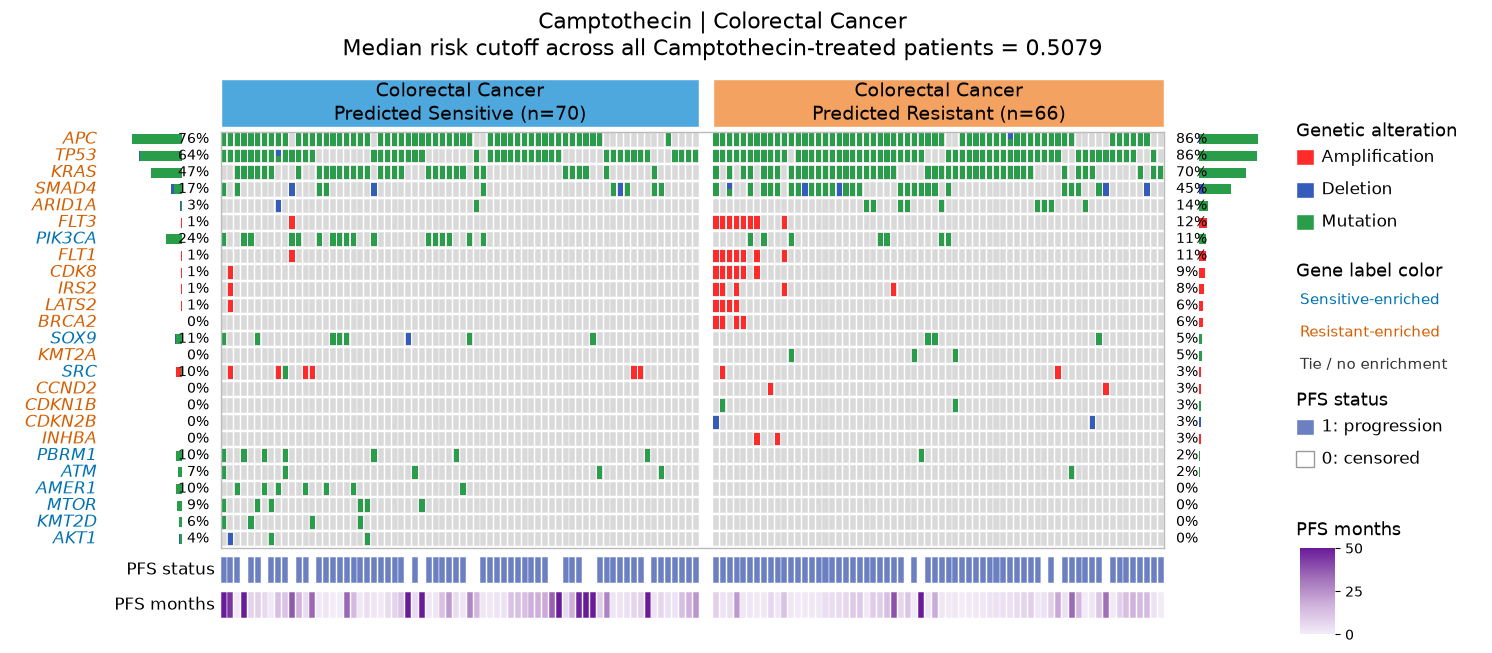

In [9]:
out = make_msk_resistance_oncoprint(
    risk_table="msk_embedding_transfer_mlp_cox_ph_risk_1_risk_scores.tsv",
    patient_table="msk_patients_rsi_drugs.txt",
    mutation_file="cell2mutation_msk.txt",
    amplification_file="cell2cnamplification_msk.txt",
    deletion_file="cell2cndeletion_msk.txt",
    patient2ind_file="patient2ind_msk.txt",
    gene2ind_file="gene2ind_ctg_av.txt",
    drug_name="Camptothecin",
    cancer_type="Colorectal Cancer",
    gene_list=None,   # or your list of genes
    top_n=25,
    figsize=(19, 7),
    #out_svg="gemictabine_pancreatic_oncoprint.svg",
)

### Genes in important system

#### Cell line important system

In [64]:
import numpy as np
import pandas as pd
from functools import lru_cache


@lru_cache(maxsize=None)
def get_msk_chord_genes(
    gene_index_file="data/gene2ind_ctg_av.txt",
    mutation_file="data/patients/cell2mutation_msk.txt",
    amplification_file="data/patients/cell2cnamplification_msk.txt",
    deletion_file="data/patients/cell2cndeletion_msk.txt",
):
    """
    Return genes with at least one nonzero mutation, amplification, or deletion
    across all MSK-CHORD samples.
    """
    gene_mapping = pd.read_csv(
        gene_index_file,
        sep="\t",
        header=None,
        names=["index", "gene"],
    )

    gene_mapping["index"] = gene_mapping["index"].astype(int)
    gene_mapping["gene"] = gene_mapping["gene"].astype(str).str.strip()

    n_genes = gene_mapping["index"].max() + 1
    observed = np.zeros(n_genes, dtype=bool)

    alteration_files = [
        mutation_file,
        amplification_file,
        deletion_file,
    ]

    for path in alteration_files:
        with open(path) as handle:
            for line_number, line in enumerate(handle, start=1):
                values = np.fromstring(
                    line.strip().strip('"'),
                    sep=",",
                    dtype=np.int16,
                )

                if values.size != n_genes:
                    raise ValueError(
                        f"{path}, row {line_number}: found {values.size} "
                        f"genes; expected {n_genes}"
                    )

                observed |= values != 0

    return {
        gene_mapping.loc[
            gene_mapping["index"].map(lambda index: observed[index]),
            "gene",
        ].iloc[index]
        for index in range(
            len(
                gene_mapping.loc[
                    gene_mapping["index"].map(
                        lambda gene_index: observed[gene_index]
                    ),
                    "gene",
                ]
            )
        )
    }


def _load_patient_system_results(
    importance_file,
    drug_name,
    drug_col="drug",
    system_col="system",
    p_col="p_bonferroni_drug",
    score_col="raw_importance",
    chunksize=250_000,
):
    """
    Load one row per patient system for a specified drug.

    This collapses the repeated rows in the patient-level importance CSV.
    """
    header = pd.read_csv(importance_file, nrows=0)
    header.columns = header.columns.str.strip()

    required = {drug_col, system_col, p_col}
    missing = required - set(header.columns)

    if missing:
        raise ValueError(
            f"Missing required patient columns: {sorted(missing)}"
        )

    has_score = score_col in header.columns
    usecols = [drug_col, system_col, p_col]

    if has_score:
        usecols.append(score_col)

    pieces = []

    for chunk in pd.read_csv(
        importance_file,
        usecols=usecols,
        chunksize=chunksize,
    ):
        chunk.columns = chunk.columns.str.strip()

        drug_mask = (
            chunk[drug_col]
            .astype(str)
            .str.strip()
            .str.casefold()
            .eq(str(drug_name).strip().casefold())
        )

        selected = chunk.loc[drug_mask].copy()

        if selected.empty:
            continue

        selected[system_col] = (
            selected[system_col].astype(str).str.strip()
        )
        selected[p_col] = pd.to_numeric(
            selected[p_col],
            errors="coerce",
        )

        if has_score:
            selected[score_col] = pd.to_numeric(
                selected[score_col],
                errors="coerce",
            )

        pieces.append(selected)

    if not pieces:
        raise ValueError(
            f"Drug {drug_name!r} was not found in {importance_file}"
        )

    patient_results = pd.concat(pieces, ignore_index=True)
    patient_results = patient_results.dropna(
        subset=[system_col, p_col]
    )

    aggregation = {
        p_col: ["min", "max", "first"],
    }

    if has_score:
        aggregation[score_col] = "first"

    collapsed = patient_results.groupby(
        system_col,
        as_index=False,
    ).agg(aggregation)

    # Flatten the groupby column names.
    collapsed.columns = [
        system_col,
        "p_min",
        "p_max",
        p_col,
    ] + ([score_col] if has_score else [])

    # Repeated patient rows should contain the same system-level p-value.
    inconsistent = ~np.isclose(
        collapsed["p_min"],
        collapsed["p_max"],
        rtol=1e-10,
        atol=1e-12,
    )

    if inconsistent.any():
        examples = collapsed.loc[
            inconsistent, system_col
        ].head(5).tolist()

        raise ValueError(
            "Conflicting repeated patient p-values found for systems: "
            f"{examples}"
        )

    return collapsed.drop(columns=["p_min", "p_max"])


def get_top_drpt_system(
    importance_file,
    drug_name,
    data_type="cell_line",
    system_to_genes=None,
    annotation_col="Annotation",
    size_col="Size_All",
    hmp_col="p_hmp_bonf_logp",
    min_genes=None,
    max_genes=100,
    min_hmp_logp=4,
    min_drug_logp=4,
    patient_p_threshold=1e-4,
    patient_drug_col="drug",
    patient_system_col="system",
    patient_p_col="p_bonferroni_drug",
    patient_score_col="raw_importance",
):
    """
    Return the most important system for either cell-line or patient results.

    data_type:
        "cell_line":
            Uses the original log-p filtering and ranking.

        "patient":
            Requires p_bonferroni_drug < patient_p_threshold.
            Requires fewer than max_genes genes in system_to_genes.
            Selects the system with the smallest Bonferroni-corrected p-value.
    """
    data_type = data_type.lower().strip()

    if data_type not in {"cell_line", "patient"}:
        raise ValueError(
            "data_type must be either 'cell_line' or 'patient'"
        )

    # ------------------------------------------------------------------
    # Original cell-line behavior
    # ------------------------------------------------------------------
    if data_type == "cell_line":
        drug_col = f"p_bonf_{drug_name}_logp"

        df = pd.read_csv(importance_file, sep="\t")

        required_cols = {
            annotation_col,
            size_col,
            hmp_col,
            drug_col,
        }

        missing = required_cols - set(df.columns)

        if missing:
            raise ValueError(
                f"Missing required columns: {missing}\n"
                f"Expected drug-specific column: {drug_col}"
            )

        df = df.copy()
        df[size_col] = pd.to_numeric(
            df[size_col], errors="coerce"
        )
        df[hmp_col] = pd.to_numeric(
            df[hmp_col], errors="coerce"
        )
        df[drug_col] = pd.to_numeric(
            df[drug_col], errors="coerce"
        )

        keep = (
            df[size_col].lt(max_genes)
            & df[hmp_col].gt(min_hmp_logp)
            & df[drug_col].gt(min_drug_logp)
        )

        if min_genes is not None:
            keep &= df[size_col].ge(min_genes)

        filtered = df.loc[keep].copy()

        if filtered.empty:
            return {
                "data_type": "cell_line",
                "drug_name": drug_name,
                "system": None,
                "n_genes": None,
                "hmp_logp": None,
                "drug_logp": None,
                "message": "No system passed the filters.",
            }

        filtered = filtered.sort_values(
            by=[drug_col, hmp_col, size_col],
            ascending=[False, False, True],
        )

        top = filtered.iloc[0]

        return {
            "data_type": "cell_line",
            "drug_name": drug_name,
            "system": top[annotation_col],
            "n_genes": int(top[size_col]),
            "hmp_logp": float(top[hmp_col]),
            "drug_logp": float(top[drug_col]),
            "drug_column": drug_col,
            "top_row": top,
            "filtered_table": filtered,
        }

    # ------------------------------------------------------------------
    # Patient behavior
    # ------------------------------------------------------------------
    if system_to_genes is None:
        raise ValueError(
            "system_to_genes must be supplied for patient analysis"
        )

    # Normalize the system-to-gene dictionary.
    cleaned_system_to_genes = {
        str(system).strip(): {
            str(gene).strip()
            for gene in genes
            if str(gene).strip()
        }
        for system, genes in system_to_genes.items()
    }

    patient_results = _load_patient_system_results(
        importance_file=importance_file,
        drug_name=drug_name,
        drug_col=patient_drug_col,
        system_col=patient_system_col,
        p_col=patient_p_col,
        score_col=patient_score_col,
    )

    patient_results["n_cell_line_genes"] = (
        patient_results[patient_system_col].map(
            lambda system: len(
                cleaned_system_to_genes.get(system, set())
            )
        )
    )

    # Exclude systems missing from the dictionary.
    patient_results["in_system_dictionary"] = (
        patient_results[patient_system_col].isin(
            cleaned_system_to_genes
        )
    )

    keep = (
        patient_results["in_system_dictionary"]
        & patient_results["n_cell_line_genes"].lt(max_genes)
        & patient_results[patient_p_col].lt(
            patient_p_threshold
        )
    )

    if min_genes is not None:
        keep &= patient_results["n_cell_line_genes"].ge(
            min_genes
        )

    filtered = patient_results.loc[keep].copy()

    if filtered.empty:
        return {
            "data_type": "patient",
            "drug_name": drug_name,
            "system": None,
            "n_cell_line_genes": None,
            "n_msk_chord_genes": None,
            "bonferroni_p_value": None,
            "message": (
                "No patient system passed the Bonferroni and "
                "system-size filters."
            ),
        }

    # Rank first by the smallest corrected p-value. If tied, rank by
    # absolute importance and then by smaller system size.
    if patient_score_col in filtered.columns:
        filtered["absolute_importance"] = (
            filtered[patient_score_col].abs()
        )

        filtered = filtered.sort_values(
            by=[
                patient_p_col,
                "absolute_importance",
                "n_cell_line_genes",
            ],
            ascending=[True, False, True],
        )
    else:
        filtered = filtered.sort_values(
            by=[
                patient_p_col,
                "n_cell_line_genes",
            ],
            ascending=[True, True],
        )

    top = filtered.iloc[0]
    top_system = top[patient_system_col]

    msk_chord_genes = get_msk_chord_genes()
    system_genes = cleaned_system_to_genes[top_system]
    system_msk_genes = sorted(system_genes & msk_chord_genes)

    result = {
        "data_type": "patient",
        "drug_name": drug_name,
        "system": top_system,
        "n_cell_line_genes": len(system_genes),
        "n_msk_chord_genes": len(system_msk_genes),
        "msk_chord_genes": system_msk_genes,
        "bonferroni_p_value": float(top[patient_p_col]),
        "p_value_threshold": patient_p_threshold,
        "top_row": top,
        "filtered_table": filtered,
    }

    if patient_score_col in top.index:
        result["raw_importance"] = float(
            top[patient_score_col]
        )
        result["absolute_importance"] = abs(
            float(top[patient_score_col])
        )

    return result

In [85]:
top_cell_line_system = get_top_drpt_system(
    importance_file="drpt_system_importance.txt",
    drug_name="Camptothecin",
    data_type="cell_line",
    system_to_genes=system_to_genes,
    patient_p_threshold=1e-4,
    max_genes=100,
)

top_cell_line_system["system"]

'Regulation of beta catenin transcriptional activity'

/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_7053/1291032756.py:681: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


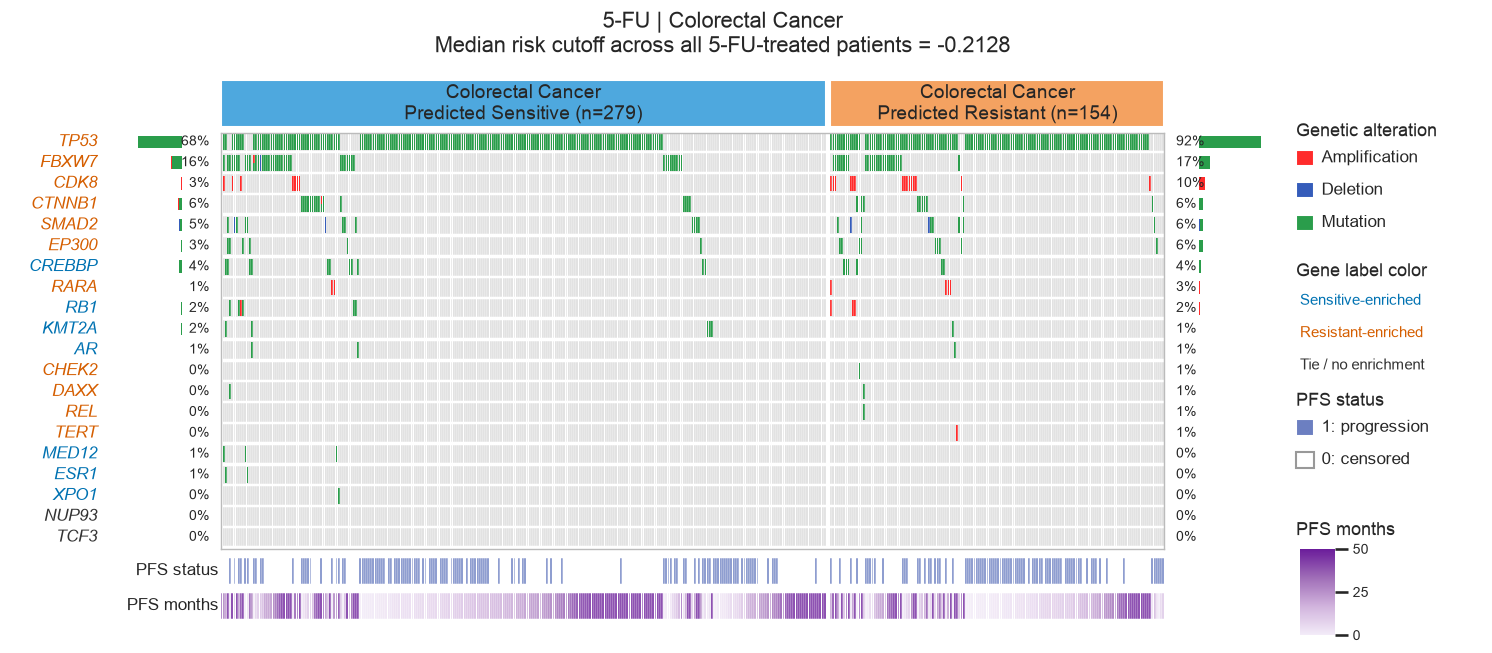

In [91]:
gene_list = list(set(set(system_to_genes["Transcription factor (TF) binding"]).union(set(system_to_genes["Nuclear pore"]))).union(set(system_to_genes["Mediator complex"])))
gene_list = list(set(gene_list).union(set(system_to_genes["Regulation of beta catenin transcriptional activity"])))

out = make_msk_resistance_oncoprint(
    risk_table="msk_embedding_transfer_mlp_cox_ph_risk_1_risk_scores.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
    mutation_file="data/patients/cell2mutation_msk.txt",
    amplification_file="data/patients/cell2cnamplification_msk.txt",
    deletion_file="data/patients/cell2cndeletion_msk.txt",
    patient2ind_file="data/patients/patient2ind_msk.txt",
    gene2ind_file="data/gene2ind_ctg_av.txt",
    drug_name="5-FU",
    cancer_type="Colorectal Cancer",
    gene_list=gene_list,   # or your list of genes
    top_n=25,
    figsize=(19, 7),
    #out_svg="gemictabine_pancreatic_oncoprint.svg",
)

#### Patient important system

In [62]:
top_patient_system = get_top_drpt_system(
    importance_file=(
        "msk_drpt_patient_importance_system_importance.csv"
    ),
    drug_name="5-FU",
    data_type="patient",
    system_to_genes=system_to_genes,
    patient_p_threshold=1e-4,
    max_genes=100,
)

top_patient_system["system"]

'Ubiquitin regulation of p53 activity'

/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_7053/1291032756.py:681: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


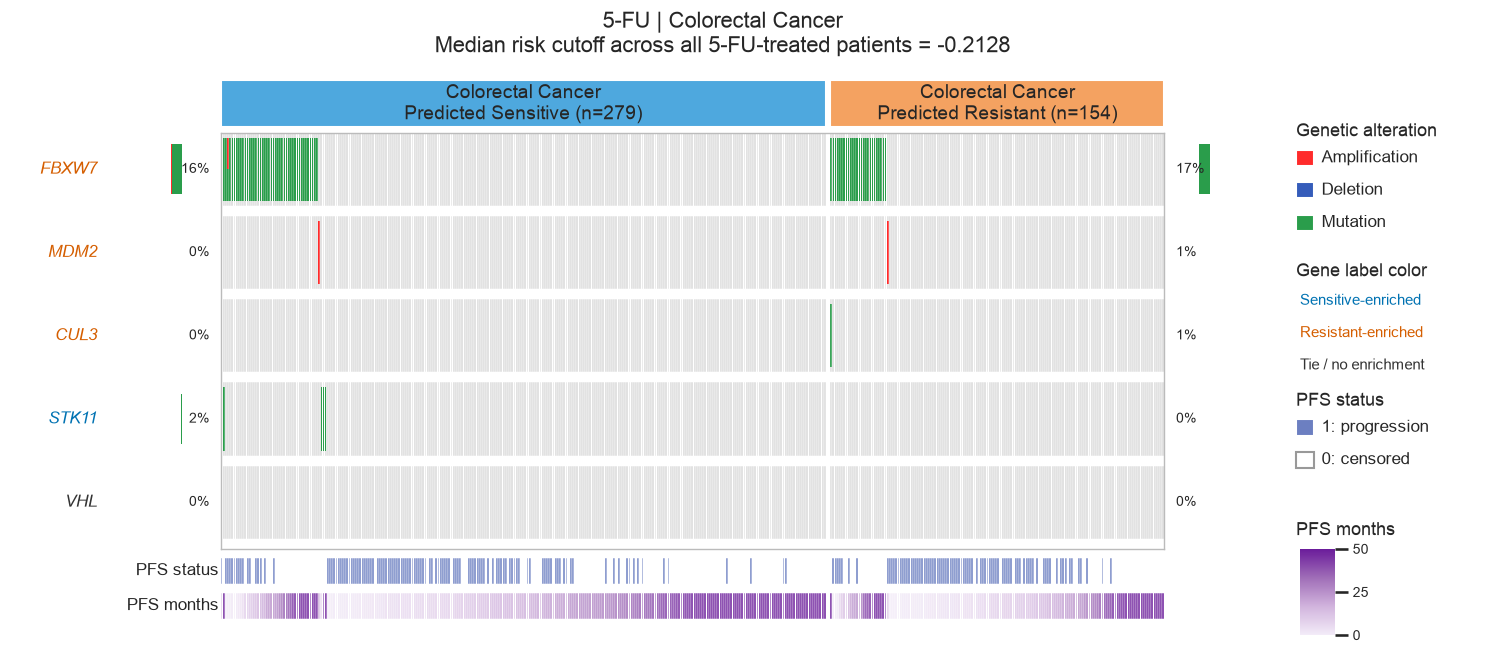

In [63]:
out = make_msk_resistance_oncoprint(
    risk_table="msk_embedding_transfer_mlp_cox_ph_risk_1_risk_scores.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
    mutation_file="data/patients/cell2mutation_msk.txt",
    amplification_file="data/patients/cell2cnamplification_msk.txt",
    deletion_file="data/patients/cell2cndeletion_msk.txt",
    patient2ind_file="data/patients/patient2ind_msk.txt",
    gene2ind_file="data/gene2ind_ctg_av.txt",
    drug_name="5-FU",
    cancer_type="Colorectal Cancer",
    gene_list=list(system_to_genes["Ubiquitin regulation of p53 activity"]),   # or your list of genes
    top_n=25,
    figsize=(19, 7),
    #out_svg="gemictabine_pancreatic_oncoprint.svg",
)

In [79]:
top_genes = top_msk_genes_for_drug(
    drug="Camptothecin",
    gene_importance_csv="gene_semi_partial_importance_g2d.csv",
    top_n=20,
    bonferroni_threshold=0.05,
)

len(top_genes)

20

In [8]:
out = make_msk_resistance_oncoprint(
    risk_table="msk_embedding_transfer_mlp_cox_ph_risk_1_risk_scores.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
    mutation_file="data/patients/cell2mutation_msk.txt",
    amplification_file="data/patients/cell2cnamplification_msk.txt",
    deletion_file="data/patients/cell2cndeletion_msk.txt",
    patient2ind_file="data/patients/patient2ind_msk.txt",
    gene2ind_file="data/gene2ind_ctg_av.txt",
    drug_name="Camptothecin",
    cancer_type="Colorectal Cancer",
    gene_list=top_genes,   # or your list of genes
    top_n=20,
    figsize=(19, 7),
    #out_svg="gemictabine_pancreatic_oncoprint.svg",
)

NameError: name 'make_msk_resistance_oncoprint' is not defined

#### Patient important genes

In [21]:
top_patient_genes = top_msk_genes_for_drug(
    drug="5-FU",
    gene_importance_csv="msk_drpt_patient_importance_gene_importance.csv",
    top_n=20,
    bonferroni_threshold=0.05,
)

len(top_patient_genes)

20

/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_7053/1291032756.py:681: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


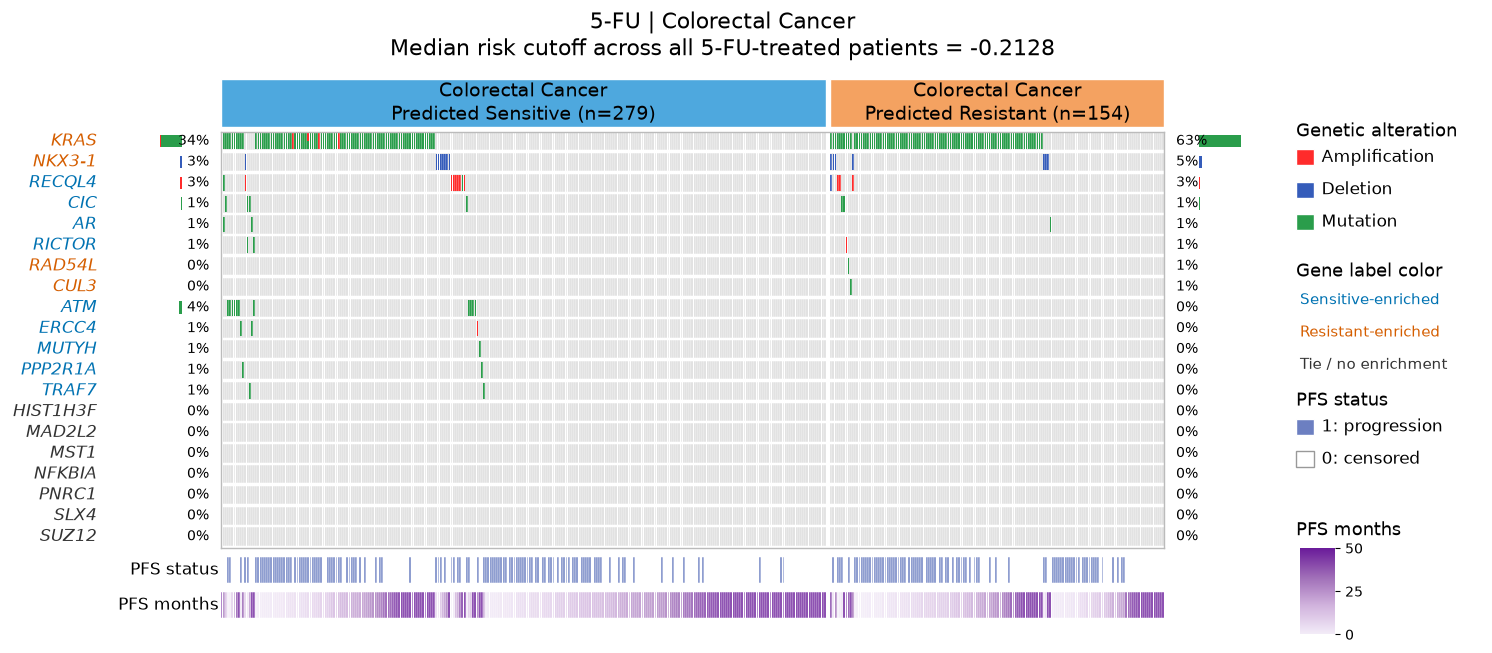

In [22]:
out = make_msk_resistance_oncoprint(
    risk_table="msk_embedding_transfer_mlp_cox_ph_risk_1_risk_scores.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
    mutation_file="data/patients/cell2mutation_msk.txt",
    amplification_file="data/patients/cell2cnamplification_msk.txt",
    deletion_file="data/patients/cell2cndeletion_msk.txt",
    patient2ind_file="data/patients/patient2ind_msk.txt",
    gene2ind_file="data/gene2ind_ctg_av.txt",
    drug_name="5-FU",
    cancer_type="Colorectal Cancer",
    gene_list=top_patient_genes,   # or your list of genes
    top_n=20,
    figsize=(19, 7),
    #out_svg="gemictabine_pancreatic_oncoprint.svg",
)